#I. Notebook Description: Data Processing and Dashboard Creation for Feedstuff Analysis

This notebook details the comprehensive process of loading, cleaning, and preparing feedstuff analysis data from four distinct subsets, followed by the compilation of aggregated dashboards for both gas production and nutritional values. Initially, data from CSV files for information samples, gas production, and nutrition are loaded into pandas DataFrames. A series of cleaning functions are then applied to standardize data, including removing header duplicates, normalizing ID suffixes (e.g., `-1`), enforcing consistent lab ID formats (e.g., FXX-XXXX), and mapping functional groups to a unified taxonomy (e.g., 'Grass', 'Shrub_Trees', 'Herbaceous_legumes'). SQL queries are used to join the cleaned information samples with gas production and nutrition data, generating sorted and consolidated DataFrames (e.g., `subset_X_gas_sorted_by_sql`, `subset_X_nutrition_sorted_by_sql`). These subset-specific DataFrames are subsequently concatenated into master DataFrames (e.g., `subsets_1_2_3_4_gas_sorted_by_sql`, `subsets_1_2_3_4_nutrition_sorted_by_sql`). Finally, dashboard-ready DataFrames are created by converting relevant columns to appropriate types and aggregating numerical features by `id` (calculating mean values) and retaining the first occurrence for categorical features, resulting in summarized datasets such as `subsets_1_2_3_4_gas_dashboard_complete` and `subsets_1_2_3_4_nutrition_dashboard_complete`.

# II. Libraries

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import sqlite3

# III. Cleaning functions

In [3]:
# Function to remove the first row (duplicated original column names)
def remove_first_row(df):
    return df.iloc[1:, :].copy()

# Usage:
# subset_1_information_samples = remove_first_row(subset_1_information_samples)

In [4]:
# Function to clean and standardize lab/sample IDs to FXX-XXXX format
def clean_lab_ids(series):
    return (
        series
        .astype(str)
        .str.replace(r'\s+', '-', regex=True)                 # Replace spaces with -
        .str.replace(r'^(F\d{2})(\d+)', r'\1-\2', regex=True) # Format FXX-XXXX
    )


# Usage:
# subset_1_information_samples['10_ciat_lab_id'] = clean_lab_ids(subset_1_information_samples['10_ciat_lab_id'])

In [5]:
# Function to clean and standardize Gene Bank - Breeding program IDs
def clean_standardize_ids(series):
    return (
        series
        .astype(str)
        .str.replace(r'-1$', '', regex=True)                   # Remove trailing -1
        .str.strip()                                           # Remove leading/trailing spaces
        .str.replace(r'[_\s]+', '-', regex=True)               # Replace spaces/underscores with -
        .str.replace(r'([A-Za-z])(\d)', r'\1-\2', regex=True)  # Letter followed by number
        .str.replace(r'(\d)([A-Za-z])', r'\1-\2', regex=True)  # Number followed by letter
        .str.replace(r'-+', '-', regex=True)                   # Remove repeated -
        .str.replace(r'^-|-$', '', regex=True)                 # Remove leading/trailing -
        .str.replace('ABC-', 'CIAT-', regex=False)             # Replace id's strings 'ABC' with 'CIAT'
    )

    # subset_1_information_samples['10_gene_bank_breeding_program_id'] = clean_standardize_ids(subset_1_information_samples['10_gene_bank_breeding_program_id'])

# 1. Subset 1

## 1.1. Loading data

In [6]:
# Load the CSVs from Drive into pandas DataFrames
subset_1_information_samples = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_05_29_sql_data_frame_creation_for_methane_intensity_and_tddm_estimations/subset_1/csv/10_information_samples.csv', encoding='latin1')
subset_1_gas_prod = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_05_29_sql_data_frame_creation_for_methane_intensity_and_tddm_estimations/subset_1/csv/31_gas_prod.csv', encoding='latin1')
subset_1_nutrition = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_05_29_sql_data_frame_creation_for_methane_intensity_and_tddm_estimations/subset_1/csv/40_result_nutrition_raw_data_vf.csv', encoding='latin1')
subset_1_digest = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_05_29_sql_data_frame_creation_for_methane_intensity_and_tddm_estimations/subset_1/csv/32_digest.csv', encoding='latin1')

## 1.2. Cleaning and formatting dataframes

In [7]:
# Clean first row containing orignal column names from excel files
subset_1_information_samples = remove_first_row(subset_1_information_samples)
subset_1_gas_prod = remove_first_row(subset_1_gas_prod)
subset_1_nutrition = remove_first_row(subset_1_nutrition)
subset_1_digest = remove_first_row(subset_1_digest)

# Add '-' to lab ids and ensure correct format FXX-XXXX
subset_1_information_samples['10_ciat_lab_id'] = clean_lab_ids(subset_1_information_samples['10_ciat_lab_id'])
subset_1_gas_prod['31_ciat_id'] = clean_lab_ids(subset_1_gas_prod['31_ciat_id'])
subset_1_nutrition['40nutrition_sample_id'] = clean_lab_ids(subset_1_nutrition['40nutrition_sample_id'])
subset_1_digest['32_ciat_id'] = clean_lab_ids(subset_1_digest['32_ciat_id'])


# Clean and standardize gene bank and breeding program ids
subset_1_information_samples['10_gene_bank_breeding_program_id'] = clean_standardize_ids(subset_1_information_samples['10_gene_bank_breeding_program_id'])
subset_1_gas_prod['31_gene_bank_id'] = clean_standardize_ids(subset_1_gas_prod['31_gene_bank_id'])
subset_1_nutrition['40nutrition_gene_bank_breeding_program_id'] = clean_standardize_ids(subset_1_nutrition['40nutrition_gene_bank_breeding_program_id'])
subset_1_digest['32_gene_bank_id'] = clean_standardize_ids(subset_1_digest['32_gene_bank_id'])

In [8]:
# Check functional groups categories
subset_1_information_samples['10_functional_group'].unique()

array(['Herbaceous', 'Climber', 'Shrub', 'Tree', 'Grass', 'FAO', 'Legume',
       'Browse', 'Forage', 'Concentrate', 'Grasses', nan], dtype=object)

In [9]:
# Define the mapping for functional groups
functional_group_mapping = {
    'Grasses': 'Grass',
    'grasses': 'Grass',
    'Shrub': 'Shrub_Trees',
    'Shrub/tree': 'Shrub_Trees',
    'Shrub/Tree': 'Shrub_Trees',
    'Shrub/Trees': 'Shrub_Trees',
    'Shrub_Trees': 'Shrub_Trees',
    'Tree': 'Shrub_Trees',
    'Arbustiva ': 'Shrub_Trees',
    'Herbáceas': 'Herbaceous_legumes',
    'Herbáceas ': 'Herbaceous_legumes',
    'Herbaceous': 'Herbaceous_legumes',
    'Herbaceous legume': 'Herbaceous_legumes',
    'Climber': 'Herbaceous_legumes',
    'Legume': 'Herbaceous_legumes'
}

# Apply the mapping to centers datt
subset_1_information_samples['10_functional_group'] = subset_1_information_samples['10_functional_group'].replace(functional_group_mapping)

print('Updated functional group counts for subset_1_information_samples:')
display(subset_1_information_samples['10_functional_group'].value_counts())

Updated functional group counts for subset_1_information_samples:


,count
10_functional_group,
Herbaceous_legumes,145
Grass,72
Shrub_Trees,31
Concentrate,7
Forage,6
Browse,4
FAO,1


## 1.3. SQL query and dataframe creation

### 1.3.1. Gas

In [81]:
# Reconnect to an in-memory SQLite database (since it was closed previously)
conn_new = sqlite3.connect(':memory:')

# Reload the pandas DataFrames into SQL tables in the database
subset_1_information_samples.to_sql('subset_1_information_samples', conn_new, if_exists='replace', index=False)
subset_1_gas_prod.to_sql('subset_1_gas_prod', conn_new, if_exists='replace', index=False)
subset_1_digest.to_sql('subset_1_digest', conn_new, if_exists='replace', index=False)
print("DataFrames reloaded as tables in SQLite.")

DataFrames reloaded as tables in SQLite.


In [11]:
subset_1_information_samples.columns

Index(['10_sample_serial_no', '10_date', '10_requisitioner', '10_set_ciat',
       '10_ciat_lab_id', '10_gene_bank_breeding_program_id', '10_genus',
       '10_species', '10_tax_name', '10_family', '10_order',
       '10_functional_group', '10_remarks', '10_id_lab'],
      dtype='object')

In [40]:
subset_1_gas_prod.columns

Index(['31_no', '31_date', '31_requisitioner', '31_gene_bank_id', '31_genus',
       '31_species', '31_tax_name', '31_family', '31_order',
       '31_functional_group', '31_ciat_id', '31_set_ciat', '31_batch',
       '31_run', '31_replication', '31_syrange_no', '31_sample_weight_g',
       '31_dm_incubated_mg', '31_digested_feed_mg', '31_time_0h',
       '31_gas_0h_ml', '31_time_8h', '31_gas_8h_ml', '31_ch4_8h_percentage',
       '31_v8_push_back_ml', '31_time_24_h', '31_gas_24h_ml',
       '31_ch4_24h_percentage', '31_remarks', '31_gp_8h_ml', '31_gp_8_24h_ml',
       '31_net_gas_8h_ml', '31_net_gas_24h_ml2', '31_net_gas_24h_ml',
       '31_ch4_8h_ml', '31_ch4_8_24h_ml', '31_ch4_24h_ml',
       '31_gas_ml_g_dm_incubated_24h', '31_percentage_dmd_truly_digestibility',
       '31_part_fact', '31_ch4_ml_in_gas_8h', '31_ch4_ml_in_gas_24h',
       '31_ch4_ml_g_dm_incubaed_24h', '31_ch4_ml_g_dmd_24h',
       '31_ch4_ml_g_ndf_digested_in_24h', '31_ch4_g_g_dm_incubated_24h',
       '31_ch4_g_g_

In [80]:
subset_1_digest.columns

Index(['32_no', '32_date', '32_gene_bank_id', '32_name', '32_ciat_id',
       '32_set_ciat', '32_batch', '32_run', '32_replication', '32_syrange_no',
       '32_bag_weight_g', '32_digested_weight_g', '32_remarks',
       '32_undigested_dm_g', '32_digested_feed_mg',
       '32_dmd_truly_digestibility', '32_ndf_incubated_mg',
       '32_ndf_digestibility_mg', '32_ndf_digestibility_in_24h',
       '32_remarks_2', 'Unnamed: 20', 'Unnamed: 21'],
      dtype='object')

In [82]:
query_combined = """
SELECT
    s1g."31_no" as no,
    s1i."10_requisitioner" as requisitioner,
    s1i."10_ciat_lab_id" as id_lab,
    s1i."10_gene_bank_breeding_program_id" as id,
    s1i."10_order" as tax_order,
    s1i."10_family" as family,
    s1i."10_genus" as genus,
    s1i."10_species" as species,
    s1i."10_tax_name" as tax_name,
    s1i."10_functional_group" as functional_group,

    s1g."31_set_ciat" as set_ciat,
    s1g."31_batch" as batch,
    s1g."31_run" as run,
    s1g."31_replication" as replication,
    s1g."31_syrange_no" as syrange,

    s1g."31_net_gas_8h_ml" as net_gas_8h_ml,
    s1g."31_net_gas_24h_ml" as net_gas_24h_ml,

    s1g."31_ch4_8h_ml" as ch4_8h_ml,
    s1g."31_ch4_24h_ml" as ch4_24h_ml,

    s1g."31_ch4_8h_percentage" as ch4_percentage_in_gas_8h,
    s1g."31_ch4_ml_in_gas_24h" as ch4_percentage_in_gas_24h,

    s1g."31_gas_ml_g_dm_incubated_24h"
        as gas_ml_g_dm_incubated_24h,

    s1g."31_ch4_ml_g_ndf_digested_in_24h"
        as ch4_ml_g_ndf_digested_24h,

    s1g."31_ch4_ml_g_dmd_24h"
        as methane_intensity,

    s1g."31_percentage_dmd_truly_digestibility"
        as tddm,

    s1d."32_undigested_dm_g"
        as new_undigested_dm_g

FROM subset_1_information_samples AS s1i

JOIN subset_1_gas_prod AS s1g
ON s1i."10_ciat_lab_id" = s1g."31_ciat_id"

LEFT JOIN subset_1_digest AS s1d
ON s1g."31_ciat_id" = s1d."32_ciat_id"
AND s1g."31_no" = s1d."32_no"
AND s1g."31_replication" = s1d."32_replication"
AND s1g."31_syrange_no" = s1d."32_syrange_no"



ORDER BY
    CAST(no AS INTEGER) ASC
"""

subset_1_gas_sorted_by_sql  = pd.read_sql_query(query_combined, conn_new)

print("Result of the combined SQL query:")
display(subset_1_gas_sorted_by_sql)

conn_new.close()
print("\nSQLite connection closed.")

Result of the combined SQL query:


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_undigested_dm_g
0,3,Genetic bank,F24-3416,CIAT-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,Herbaceous_legumes,...,62.57735271,4.00052554,11.15669017,14.2,17.82863877,135.9455554,227.8476704,37.05164527,65.41475234,0.1592
1,4,Genetic bank,F24-3416,CIAT-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,Herbaceous_legumes,...,61.24984258,4.22590726,11.20518116,15,18.29422035,133.168047,270.0095702,38.18507666,63.79993989,0.1665
2,5,Genetic bank,F24-3416,CIAT-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,Herbaceous_legumes,...,63.01985609,4.071031078,10.97607504,13.8,17.41685196,137.0163711,249.4607864,37.08835285,64.34348434,0.164
3,6,Genetic bank,F24-3417,CIAT-707,Fabales,Fabaceae,Alysicarpus,ovalifolius,Alysicarpus ovalifolius,Herbaceous_legumes,...,67.00238649,4.285055212,11.30293754,13.9,16.86945515,148.7414028,175.9559634,41.7140678,60.15204354,0.1795
4,7,Genetic bank,F24-3417,CIAT-707,Fabales,Fabaceae,Alysicarpus,ovalifolius,Alysicarpus ovalifolius,Herbaceous_legumes,...,66.11737974,4.130031528,11.23375951,14,16.99063023,146.6594117,149.5197103,39.832832,62.55733546,0.1688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,2302,LMF,F25-0018,Homenheim-Concentrate,Concentrate,Concentrate,Homenheim,Concentrate,Homenheim Concentrate,Concentrate,...,56.45605598,4.528874573,9.221180394,15.2,16.33337688,251.6736968,#DIV/0!,67.10098338,61.26111917,0.0869
3596,2302,LMF,F25-0018,Homenheim-Concentrate,Concentrate,Concentrate,Homenheim,Concentrate,Homenheim Concentrate,Concentrate,...,56.45605598,4.528874573,9.221180394,15.2,16.33337688,251.6736968,#DIV/0!,67.10098338,61.26111917,0.0869
3597,2302,LMF,F25-0018,Homenheim-Concentrate,Concentrate,Concentrate,Homenheim,Concentrate,Homenheim Concentrate,Concentrate,...,56.45605598,4.528874573,9.221180394,15.2,16.33337688,251.6736968,#DIV/0!,67.10098338,61.26111917,0.0869
3598,2302,LMF,F25-0018,Homenheim-Concentrate,Concentrate,Concentrate,Homenheim,Concentrate,Homenheim Concentrate,Concentrate,...,56.45605598,4.528874573,9.221180394,15.2,16.33337688,251.6736968,#DIV/0!,67.10098338,61.26111917,0.0869



SQLite connection closed.


In [83]:
# Remove duplicate rows, keeping the first occurrence
subset_1_gas_sorted_by_sql = subset_1_gas_sorted_by_sql.drop_duplicates(keep='first')

print("Shape of DataFrame after removing duplicates (keeping first):", subset_1_gas_sorted_by_sql.shape)
print("First 5 rows of DataFrame without duplicates (keeping first):")
display(subset_1_gas_sorted_by_sql.head())

Shape of DataFrame after removing duplicates (keeping first): (2277, 26)
First 5 rows of DataFrame without duplicates (keeping first):


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_undigested_dm_g
0,3,Genetic bank,F24-3416,CIAT-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,Herbaceous_legumes,...,62.57735271,4.00052554,11.15669017,14.2,17.82863877,135.9455554,227.8476704,37.05164527,65.41475234,0.1592
1,4,Genetic bank,F24-3416,CIAT-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,Herbaceous_legumes,...,61.24984258,4.22590726,11.20518116,15,18.29422035,133.168047,270.0095702,38.18507666,63.79993989,0.1665
2,5,Genetic bank,F24-3416,CIAT-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,Herbaceous_legumes,...,63.01985609,4.071031078,10.97607504,13.8,17.41685196,137.0163711,249.4607864,37.08835285,64.34348434,0.164
3,6,Genetic bank,F24-3417,CIAT-707,Fabales,Fabaceae,Alysicarpus,ovalifolius,Alysicarpus ovalifolius,Herbaceous_legumes,...,67.00238649,4.285055212,11.30293754,13.9,16.86945515,148.7414028,175.9559634,41.7140678,60.15204354,0.1795
4,7,Genetic bank,F24-3417,CIAT-707,Fabales,Fabaceae,Alysicarpus,ovalifolius,Alysicarpus ovalifolius,Herbaceous_legumes,...,66.11737974,4.130031528,11.23375951,14,16.99063023,146.6594117,149.5197103,39.832832,62.55733546,0.1688


In [84]:
# Add a new column 'subset' at the beginning of the DataFrame with value 1
subset_1_gas_sorted_by_sql.insert(0, 'subset', 1)

print("DataFrame with new 'subset' column:")
display(subset_1_gas_sorted_by_sql.head())

DataFrame with new 'subset' column:


,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_undigested_dm_g
0,1,3,Genetic bank,F24-3416,CIAT-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,...,62.57735271,4.00052554,11.15669017,14.2,17.82863877,135.9455554,227.8476704,37.05164527,65.41475234,0.1592
1,1,4,Genetic bank,F24-3416,CIAT-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,...,61.24984258,4.22590726,11.20518116,15,18.29422035,133.168047,270.0095702,38.18507666,63.79993989,0.1665
2,1,5,Genetic bank,F24-3416,CIAT-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,...,63.01985609,4.071031078,10.97607504,13.8,17.41685196,137.0163711,249.4607864,37.08835285,64.34348434,0.164
3,1,6,Genetic bank,F24-3417,CIAT-707,Fabales,Fabaceae,Alysicarpus,ovalifolius,Alysicarpus ovalifolius,...,67.00238649,4.285055212,11.30293754,13.9,16.86945515,148.7414028,175.9559634,41.7140678,60.15204354,0.1795
4,1,7,Genetic bank,F24-3417,CIAT-707,Fabales,Fabaceae,Alysicarpus,ovalifolius,Alysicarpus ovalifolius,...,66.11737974,4.130031528,11.23375951,14,16.99063023,146.6594117,149.5197103,39.832832,62.55733546,0.1688


### 1.3.2. Nutrition

In [86]:
# Reconnect to an in-memory SQLite database (since it was closed previously)
conn_new = sqlite3.connect(':memory:')

# Reload the pandas DataFrames into SQL tables in the database
subset_1_information_samples.to_sql('subset_1_information_samples', conn_new, if_exists='replace', index=False)
subset_1_nutrition.to_sql('subset_1_nutrition', conn_new, if_exists='replace', index=False)

print("DataFrames reloaded as tables in SQLite.")

DataFrames reloaded as tables in SQLite.


In [87]:
subset_1_information_samples.columns

Index(['10_sample_serial_no', '10_date', '10_requisitioner', '10_set_ciat',
       '10_ciat_lab_id', '10_gene_bank_breeding_program_id', '10_genus',
       '10_species', '10_tax_name', '10_family', '10_order',
       '10_functional_group', '10_remarks', '10_id_lab'],
      dtype='object')

In [88]:
subset_1_nutrition.columns

Index(['40nutrition_no', '40nutrition_date', '40nutrition_requisitioner',
       '40nutrition_set_ciat', '40nutrition_sample_id',
       '40nutrition_gene_bank_breeding_program_id', '40nutrition_genus',
       '40nutrition_species', '40nutrition_tax_name',
       '40nutrition_dm_percentage', '40nutrition_av_dm_105',
       '40nutrition_ash_dm', '40nutrition_av_ash_percentage',
       '40nutrition_om_percentage', '40nutrition_om_percentage.1',
       '40nutrition_pc_percentage_dm', '40nutrition_av_pc_percentage',
       '40nutrition_adf_percentage_dm', '40nutrition_av_adf_percentage_dm',
       '40nutrition_ndf_percentage_dm', '40nutrition_av_ndf_percentage_dm'],
      dtype='object')

In [89]:
query_combined = """
SELECT
    s1n."40nutrition_no" as no,
    s1i."10_requisitioner" as requisitioner,
    s1i."10_ciat_lab_id" as id_lab,
    s1i."10_gene_bank_breeding_program_id" as id,
    s1i."10_order" as tax_order,
    s1i."10_family" as family,
    s1i."10_genus" as genus,
    s1i."10_species" as species,
    s1i."10_tax_name" as tax_name,
    s1i."10_functional_group" as functional_group,
    s1n."40nutrition_set_ciat" as set_ciat,
    s1n."40nutrition_dm_percentage" as dm_percentage,
    s1n."40nutrition_ash_dm" as ash_dm,
    s1n."40nutrition_om_percentage" as om_percentage,
    s1n."40nutrition_pc_percentage_dm" as pc_percentage_dm,
    s1n."40nutrition_adf_percentage_dm" as adf_percentage_dm,
    s1n."40nutrition_ndf_percentage_dm" as ndf_percentage_dm



FROM
    subset_1_information_samples AS s1i
JOIN
    subset_1_nutrition AS s1n
ON
    s1i."10_ciat_lab_id" = s1n."40nutrition_sample_id"
ORDER BY
    CAST(no AS INTEGER) ASC
"""

subset_1_nutrition_sorted_by_sql  = pd.read_sql_query(query_combined, conn_new)

print("Result of the combined SQL query:")
display(subset_1_nutrition_sorted_by_sql)

conn_new.close()
print("\nSQLite connection closed.")

Result of the combined SQL query:


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,1,Genetic bank,F24-3416,CIAT-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,Herbaceous_legumes,1,91.93080692,12.72569067,87.27430933,33.01052157,28.48961421,45.21032889
1,2,Genetic bank,F24-3416,CIAT-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,Herbaceous_legumes,1,92.01,12.62906206,87.37093794,33.01052157,27.61265655,45.23511907
2,3,Genetic bank,F24-3417,CIAT-707,Fabales,Fabaceae,Alysicarpus,ovalifolius,Alysicarpus ovalifolius,Herbaceous_legumes,1,90.64280716,11.91132679,88.08867321,25.39749175,26.19631971,54.55645373
3,4,Genetic bank,F24-3417,CIAT-707,Fabales,Fabaceae,Alysicarpus,ovalifolius,Alysicarpus ovalifolius,Herbaceous_legumes,1,89.54209158,12.23760607,87.76239393,25.39749175,24.68485778,53.66007735
4,5,Genetic bank,F24-3418,CIAT-712,Fabales,Fabaceae,Clitoria,ternatea,Clitoria ternatea,Herbaceous_legumes,1,91.25174965,7.71337789,92.28662211,31.19171324,26.67696802,55.20337963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,376,Genetic bank,F24-3533,CIAT-32246,Fabales,Fabaceae,Chamaecrista,nictitans,Chamaecrista nictitans,Herbaceous_legumes,10,91.56,8.03,91.97,26.83,26.85895517,81.72281094
466,377,Genetic bank,F24-3534,CIAT-32365,Fabales,Fabaceae,Desmanthus,virgatus,Desmanthus virgatus,Shrub_Trees,10,90.87,7.56,92.44,30.19,28.08362098,77.86276485
467,378,Genetic bank,F24-3534,CIAT-32365,Fabales,Fabaceae,Desmanthus,virgatus,Desmanthus virgatus,Shrub_Trees,10,90.98,7.45,92.55,30.19,29.38322659,73.65060102
468,379,Genetic bank,F24-3535,CIAT-32373,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,10,92.3,8.61,91.39,28.4,20.16866025,76.26718922



SQLite connection closed.


In [90]:
# Remove duplicate rows, keeping the first occurrence
subset_1_nutrition_sorted_by_sql = subset_1_nutrition_sorted_by_sql.drop_duplicates(keep='first')

print("Shape of DataFrame after removing duplicates (keeping first):", subset_1_nutrition_sorted_by_sql.shape)
print("First 5 rows of DataFrame without duplicates (keeping first):")
display(subset_1_nutrition_sorted_by_sql.head())

Shape of DataFrame after removing duplicates (keeping first): (388, 17)
First 5 rows of DataFrame without duplicates (keeping first):


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,1,Genetic bank,F24-3416,CIAT-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,Herbaceous_legumes,1,91.93080692,12.72569067,87.27430933,33.01052157,28.48961421,45.21032889
1,2,Genetic bank,F24-3416,CIAT-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,Herbaceous_legumes,1,92.01,12.62906206,87.37093794,33.01052157,27.61265655,45.23511907
2,3,Genetic bank,F24-3417,CIAT-707,Fabales,Fabaceae,Alysicarpus,ovalifolius,Alysicarpus ovalifolius,Herbaceous_legumes,1,90.64280716,11.91132679,88.08867321,25.39749175,26.19631971,54.55645373
3,4,Genetic bank,F24-3417,CIAT-707,Fabales,Fabaceae,Alysicarpus,ovalifolius,Alysicarpus ovalifolius,Herbaceous_legumes,1,89.54209158,12.23760607,87.76239393,25.39749175,24.68485778,53.66007735
4,5,Genetic bank,F24-3418,CIAT-712,Fabales,Fabaceae,Clitoria,ternatea,Clitoria ternatea,Herbaceous_legumes,1,91.25174965,7.71337789,92.28662211,31.19171324,26.67696802,55.20337963


In [91]:
# Add a new column 'subset' at the beginning of the DataFrame with value 1
subset_1_nutrition_sorted_by_sql.insert(0, 'subset', 1)

print("DataFrame with new 'subset' column:")
display(subset_1_nutrition_sorted_by_sql.head())

DataFrame with new 'subset' column:


,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,1,1,Genetic bank,F24-3416,CIAT-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,Herbaceous_legumes,1,91.93080692,12.72569067,87.27430933,33.01052157,28.48961421,45.21032889
1,1,2,Genetic bank,F24-3416,CIAT-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,Herbaceous_legumes,1,92.01,12.62906206,87.37093794,33.01052157,27.61265655,45.23511907
2,1,3,Genetic bank,F24-3417,CIAT-707,Fabales,Fabaceae,Alysicarpus,ovalifolius,Alysicarpus ovalifolius,Herbaceous_legumes,1,90.64280716,11.91132679,88.08867321,25.39749175,26.19631971,54.55645373
3,1,4,Genetic bank,F24-3417,CIAT-707,Fabales,Fabaceae,Alysicarpus,ovalifolius,Alysicarpus ovalifolius,Herbaceous_legumes,1,89.54209158,12.23760607,87.76239393,25.39749175,24.68485778,53.66007735
4,1,5,Genetic bank,F24-3418,CIAT-712,Fabales,Fabaceae,Clitoria,ternatea,Clitoria ternatea,Herbaceous_legumes,1,91.25174965,7.71337789,92.28662211,31.19171324,26.67696802,55.20337963


# 2. Subset 2

## 2.1. Loading data

In [92]:
# Load the CSVs from Drive into pandas DataFrames
subset_2_information_samples = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_05_29_sql_data_frame_creation_for_methane_intensity_and_tddm_estimations/subset_2/csv/10_information_samples.csv', encoding='latin1')
subset_2_gas_prod = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_05_29_sql_data_frame_creation_for_methane_intensity_and_tddm_estimations/subset_2/csv/31_gas_prod.csv', encoding='latin1')
subset_2_nutrition = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_05_29_sql_data_frame_creation_for_methane_intensity_and_tddm_estimations/subset_2/csv/40_result_q_raw_data.csv', encoding='latin1')
subset_2_digest = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_05_29_sql_data_frame_creation_for_methane_intensity_and_tddm_estimations/subset_2/csv/32_digest.csv', encoding='latin1')

## 2.2. Cleaning and formatting dataframes

In [98]:
subset_2_digest.head()

,32_no,32_date,32_requisitioner,32_gene_bank_id,32_genus,32_species,32_tax_name,32_family,32_order,32_functional_group,...,32_bag_weight,32_digested_weight_g,32_remarks,32_undigested_dm_g,32_digested_feed_mg,32_percentage_dmd_truly_digestibility,32_ndf_incubated_mg,32_ndf_digestibility_mg,32_ndf_digestibillity_in_24h,32_remarks.1
0,No,Date,Requisitioner,Gene Bank ID,Genus,Species,Tax Name,Family,Order,Functional Group,...,"Bag weight, g","Digested weight, g",Remarks,"Undigested DM, g","Digested feed, mg","% DMD, Truly digestibility","NDF incubated, mg","NDF digestibility, mg",% NDF digestibility in 24 h,Remarks
1,1,45789,NaN,BLANK 24 H,NaN,NaN,BLANK 24 H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,45789,NaN,BLANK 24 H,NaN,NaN,BLANK 24 H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,45789,Genetic bank,ABC-32379-1,Desmanthus,pubescens,Desmanthus pubescens,Fabaceae,Fabales,Shrub,...,0.6072,0.6851,"Bolsa abierta, perdida de muestra",0.0779,386.8,83.23649666,346.782375,268.882375,77.53634394,Eliminó
4,4,45789,Genetic bank,ABC-32379-1,Desmanthus,pubescens,Desmanthus pubescens,Fabaceae,Fabales,Shrub,...,0.5856,0.8126,NaN,0.227,237.79294,51.16104819,346.8517315,119.8517315,34.55416842,NaN


In [99]:
# Clean first row containing orignal column names from excel files
subset_2_information_samples = remove_first_row(subset_2_information_samples)
subset_2_gas_prod = remove_first_row(subset_2_gas_prod)
subset_2_nutrition = remove_first_row(subset_2_nutrition)
subset_2_digest = remove_first_row(subset_2_digest)

# Add '-' to lab ids and ensure correct format FXX-XXXX
subset_2_information_samples['10_ciat_lab_id'] = clean_lab_ids(subset_2_information_samples['10_ciat_lab_id'])
subset_2_gas_prod['31_ciat_id'] = clean_lab_ids(subset_2_gas_prod['31_ciat_id'])
subset_2_nutrition['40qraw_sample_id'] = clean_lab_ids(subset_2_nutrition['40qraw_sample_id'])
subset_2_digest['32_ciat_id'] = clean_lab_ids(subset_2_digest['32_ciat_id'])

# Clean and standardize gene bank and breeding program ids
subset_2_information_samples['10_gene_bank_breeding_program_id'] = clean_standardize_ids(subset_2_information_samples['10_gene_bank_breeding_program_id'])
subset_2_gas_prod['31_gene_bank_id'] = clean_standardize_ids(subset_2_gas_prod['31_gene_bank_id'])
subset_2_nutrition['40qraw_gene_bank_breeding_program_id'] = clean_standardize_ids(subset_2_nutrition['40qraw_gene_bank_breeding_program_id'])
subset_2_digest['32_gene_bank_id'] = clean_standardize_ids(subset_2_digest['32_gene_bank_id'])


In [100]:
# Check functional groups categories
subset_2_information_samples['10_functional_group'].unique()

array(['Shrub_Trees', 'Herbaceous_legumes', 'Forage', 'Concentrate',
       'Grass', nan], dtype=object)

In [101]:
# Define the mapping for functional groups
functional_group_mapping = {
    'Grasses': 'Grass',
    'grasses': 'Grass',
    'Shrub': 'Shrub_Trees',
    'Shrub/tree': 'Shrub_Trees',
    'Shrub/Tree': 'Shrub_Trees',
    'Shrub/Trees': 'Shrub_Trees',
    'Shrub_Trees': 'Shrub_Trees',
    'Tree': 'Shrub_Trees',
    'Arbustiva ': 'Shrub_Trees',
    'Herbáceas': 'Herbaceous_legumes',
    'Herbáceas ': 'Herbaceous_legumes',
    'Herbaceous': 'Herbaceous_legumes',
    'Herbaceous legume': 'Herbaceous_legumes',
    'Climber': 'Herbaceous_legumes',
    'Legume': 'Herbaceous_legumes'
}

# Apply the mapping to centers datt
subset_2_information_samples['10_functional_group'] = subset_2_information_samples['10_functional_group'].replace(functional_group_mapping)

print('Updated functional group counts for subset_2_information_samples:')
display(subset_2_information_samples['10_functional_group'].value_counts())

Updated functional group counts for subset_2_information_samples:


,count
10_functional_group,
Grass,122
Herbaceous_legumes,109
Shrub_Trees,28
Concentrate,9
Forage,8


## 2.3. SQL query and dataframe creation

### 2.3.1. Gas

In [105]:
# Reconnect to an in-memory SQLite database (since it was closed previously)
conn_new = sqlite3.connect(':memory:')

# Reload the pandas DataFrames into SQL tables in the database
subset_2_information_samples.to_sql('subset_2_information_samples', conn_new, if_exists='replace', index=False)
subset_2_gas_prod.to_sql('subset_2_gas_prod', conn_new, if_exists='replace', index=False)
subset_2_digest.to_sql('subset_2_digest', conn_new, if_exists='replace', index=False)

print("DataFrames reloaded as tables in SQLite.")

DataFrames reloaded as tables in SQLite.


In [43]:
subset_2_information_samples.columns

Index(['10_sample_serial_no', '10_date', '10_requisitioner',
       '10_requisitioner_2', '10_set_ciat', '10_ciat_lab_id',
       '10_gene_bank_breeding_program_id', '10_genus', '10_species',
       '10_tax_name', '10_family', '10_order', '10_functional_group',
       '10_remarks', '10_id_lab', '10_remarks.1'],
      dtype='object')

In [44]:
subset_2_gas_prod.columns

Index(['31_no', '31_date', '31_requisitioner', '31_gene_bank_id', '31_genus',
       '31_species', '31_tax_name', '31_family', '31_order',
       '31_functional_group', '31_ciat_id', '31_set_ciat', '31_batch',
       '31_run', '31_replication', '31_syrange_no', '31_sample_weight_g',
       '31_dm_incubated_mg', '31_digested_feed_mg', '31_time_0h',
       '31_gas_0h_ml', '31_time_8h', '31_gas_8h_ml', '31_ch4_8h_percentage',
       '31_v8_push_back_ml', '31_time_24h', '31_gas_24h_ml',
       '31_ch4_24h_percentage', '31_remarks', '31_gp_8h_ml', '31_gp_8_24h_ml',
       '31_net_gas_8h_ml', '31_net_gas_8_24h_ml2', '31_net_gas_24h_ml',
       '31_ch4_8h_ml', '31_ch4_8_24h_ml', '31_ch4_24h_ml',
       '31_gas_ml_g_dm_incubated_24h', '31_percentage_dmd_truly_digestibility',
       '31_part_fact', '31_ch4_percentage_in_gas_8h',
       '31_ch4_percentage_in_gas_24h', '31_ch4_ml_g_dm_incubated_24h',
       '31_ch4_ml_g_dmd_24h', '31_ch4_ml_g_ndf_digested_in_24h',
       '31_ch4_g_g_dm_incubated_

In [103]:
subset_2_digest.columns

Index(['32_no', '32_date', '32_requisitioner', '32_gene_bank_id', '32_genus',
       '32_species', '32_tax_name', '32_family', '32_order',
       '32_functional_group', '32_ciat_id', '32_set_ciat', '32_batch',
       '32_run', '32_replication', '32_syrange_no', '32_bag_weight',
       '32_digested_weight_g', '32_remarks', '32_undigested_dm_g',
       '32_digested_feed_mg', '32_percentage_dmd_truly_digestibility',
       '32_ndf_incubated_mg', '32_ndf_digestibility_mg',
       '32_ndf_digestibillity_in_24h', '32_remarks.1'],
      dtype='object')

In [107]:
query_combined = """
SELECT
    s2g."31_no" as no,
    s2i."10_requisitioner" as requisitioner,
    s2i."10_ciat_lab_id" as id_lab,
    s2i."10_gene_bank_breeding_program_id" as id,
    s2i."10_order" as tax_order,
    s2i."10_family" as family,
    s2i."10_genus" as genus,
    s2i."10_species" as species,
    s2i."10_tax_name" as tax_name,
    s2i."10_functional_group" as functional_group,
    s2g."31_set_ciat" as set_ciat,
    s2g."31_batch" as batch,
    s2g."31_run" as run,
    s2g."31_replication" as replication,
    s2g."31_syrange_no" as syrange,
    s2g."31_net_gas_8h_ml" as net_gas_8h_ml,
    s2g."31_net_gas_24h_ml" as net_gas_24h_ml,
    s2g."31_ch4_8h_ml" as ch4_8h_ml,
    s2g."31_ch4_24h_ml" as ch4_24h_ml,
    s2g."31_ch4_8h_percentage" as ch4_percentage_in_gas_8h,
    s2g."31_ch4_24h_percentage" as ch4_percentage_in_gas_24h,
    s2g."31_gas_ml_g_dm_incubated_24h" as gas_ml_g_dm_incubated_24h,
    s2g."31_ch4_ml_g_ndf_digested_in_24h" as ch4_ml_g_ndf_digested_24h,
    s2g."31_ch4_ml_g_dmd_24h" as methane_intensity,
    s2g."31_percentage_dmd_truly_digestibility" as tddm,
    s2d."32_undigested_dm_g" as new_undigested_dm_g
FROM
    subset_2_information_samples AS s2i
JOIN
    subset_2_gas_prod AS s2g
ON s2i."10_ciat_lab_id" = s2g."31_ciat_id"

LEFT JOIN subset_2_digest AS s2d
ON s2g."31_ciat_id" = s2d."32_ciat_id"
AND s2g."31_no" = s2d."32_no"
AND s2g."31_replication" = s2d."32_replication"
AND s2g."31_syrange_no" = s2d."32_syrange_no"

ORDER BY
    CAST(no AS INTEGER) ASC

"""

subset_2_gas_sorted_by_sql  = pd.read_sql_query(query_combined, conn_new)

print("Result of the combined SQL query:")
display(subset_2_gas_sorted_by_sql)

conn_new.close()
print("\nSQLite connection closed.")

Result of the combined SQL query:


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_undigested_dm_g
0,6,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,...,52.14164805,3.403440982,8.602855674,13.9,18.8,111.7273306,22.38737036,46.96225419,39.25259478,0.2835
1,7,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,...,52.58415142,3.518196858,8.468039645,13.4,18.8,112.6304774,16.20638872,52.70349781,34.41474045,0.3062
2,8,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,...,52.58415142,3.348865565,8.465089622,13.2,18.8,112.6755116,23.40030415,45.2953268,40.04541806,0.2798
3,9,Genetic bank,F24-3538,CIAT-33249,Fabales,Fabaceae,Desmodium,velutinum,Desmodium velutinum,Shrub_Trees,...,62.76172912,4.734786145,10.44374348,15,18.3,134.7291624,23.79350718,56.59453311,39.61397509,0.2813
4,10,Genetic bank,F24-3538,CIAT-33249,Fabales,Fabaceae,Desmodium,velutinum,Desmodium velutinum,Shrub_Trees,...,62.76172912,4.703220904,10.38098175,14.9,18.2,134.7561028,27.35497298,52.52386839,42.43608059,0.2681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4351,2704,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,...,59.4060785,2.984685285,9.011470668,14.2,15.7,126.7080608,None,45.43396889,42.29621851,None
4352,2704,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,...,59.4060785,2.984685285,9.011470668,14.2,15.7,126.7080608,None,45.43396889,42.29621851,None
4353,2704,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,...,59.4060785,2.984685285,9.011470668,14.2,15.7,126.7080608,None,45.43396889,42.29621851,None
4354,2704,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,...,59.4060785,2.984685285,9.011470668,14.2,15.7,126.7080608,None,45.43396889,42.29621851,None



SQLite connection closed.


In [108]:
# Remove duplicate rows, keeping the first occurrence
subset_2_gas_sorted_by_sql = subset_2_gas_sorted_by_sql.drop_duplicates(keep='first')

print("Shape of DataFrame after removing duplicates (keeping first):", subset_2_gas_sorted_by_sql.shape)
print("First 5 rows of DataFrame without duplicates (keeping first):")
display(subset_2_gas_sorted_by_sql.head())

Shape of DataFrame after removing duplicates (keeping first): (2520, 26)
First 5 rows of DataFrame without duplicates (keeping first):


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_undigested_dm_g
0,6,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,...,52.14164805,3.403440982,8.602855674,13.9,18.8,111.7273306,22.38737036,46.96225419,39.25259478,0.2835
1,7,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,...,52.58415142,3.518196858,8.468039645,13.4,18.8,112.6304774,16.20638872,52.70349781,34.41474045,0.3062
2,8,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,...,52.58415142,3.348865565,8.465089622,13.2,18.8,112.6755116,23.40030415,45.2953268,40.04541806,0.2798
3,9,Genetic bank,F24-3538,CIAT-33249,Fabales,Fabaceae,Desmodium,velutinum,Desmodium velutinum,Shrub_Trees,...,62.76172912,4.734786145,10.44374348,15,18.3,134.7291624,23.79350718,56.59453311,39.61397509,0.2813
4,10,Genetic bank,F24-3538,CIAT-33249,Fabales,Fabaceae,Desmodium,velutinum,Desmodium velutinum,Shrub_Trees,...,62.76172912,4.703220904,10.38098175,14.9,18.2,134.7561028,27.35497298,52.52386839,42.43608059,0.2681


In [109]:
# Add a new column 'subset' at the beginning of the DataFrame with value 2
subset_2_gas_sorted_by_sql.insert(0, 'subset', 2)

print("DataFrame with new 'subset' column:")
display(subset_2_gas_sorted_by_sql.head())

DataFrame with new 'subset' column:


,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_undigested_dm_g
0,2,6,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,52.14164805,3.403440982,8.602855674,13.9,18.8,111.7273306,22.38737036,46.96225419,39.25259478,0.2835
1,2,7,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,52.58415142,3.518196858,8.468039645,13.4,18.8,112.6304774,16.20638872,52.70349781,34.41474045,0.3062
2,2,8,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,52.58415142,3.348865565,8.465089622,13.2,18.8,112.6755116,23.40030415,45.2953268,40.04541806,0.2798
3,2,9,Genetic bank,F24-3538,CIAT-33249,Fabales,Fabaceae,Desmodium,velutinum,Desmodium velutinum,...,62.76172912,4.734786145,10.44374348,15,18.3,134.7291624,23.79350718,56.59453311,39.61397509,0.2813
4,2,10,Genetic bank,F24-3538,CIAT-33249,Fabales,Fabaceae,Desmodium,velutinum,Desmodium velutinum,...,62.76172912,4.703220904,10.38098175,14.9,18.2,134.7561028,27.35497298,52.52386839,42.43608059,0.2681


In [111]:
subset_2_gas_sorted_by_sql[
    subset_2_gas_sorted_by_sql["id"].astype(str).str.strip() == "CIAT-32380"
]

,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_undigested_dm_g
0,2,6,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,52.14164805,3.403440982,8.602855674,13.9,18.8,111.7273306,22.38737036,46.96225419,39.25259478,0.2835
1,2,7,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,52.58415142,3.518196858,8.468039645,13.4,18.8,112.6304774,16.20638872,52.70349781,34.41474045,0.3062
2,2,8,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,52.58415142,3.348865565,8.465089622,13.2,18.8,112.6755116,23.40030415,45.2953268,40.04541806,0.2798
165,2,111,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,53.13728065,3.336032967,7.841712988,12.6,16.9,113.8607379,24.87863995,40.78138044,41.20251149,0.2744
166,2,112,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,52.69477727,3.224522116,7.804985208,12.6,16.9,112.9577219,27.42302013,38.7344179,43.19399786,0.265
167,2,113,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,54.0222874,3.472545259,7.971698356,12.9,16.6,115.8034028,29.12104758,38.38082983,44.52304394,0.2588
330,2,216,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,51.47789298,3.190744358,7.651178409,12.8,16.8,110.3271157,13.80126517,50.40524456,32.53225025,0.3148
331,2,217,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,53.24790649,3.226587132,7.753396689,12.5,16.5,114.0977832,18.96529674,45.42475326,36.57413776,0.296
332,2,218,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,53.69040987,3.390608384,7.898390296,12.7,16.7,114.9999826,25.48334307,40.59341315,41.67581262,0.2723


### 2.3.2. Nutrition

In [112]:
# Reconnect to an in-memory SQLite database (since it was closed previously)
conn_new = sqlite3.connect(':memory:')

# Reload the pandas DataFrames into SQL tables in the database
subset_2_information_samples.to_sql('subset_2_information_samples', conn_new, if_exists='replace', index=False)
subset_2_nutrition.to_sql('subset_2_nutrition', conn_new, if_exists='replace', index=False)

print("DataFrames reloaded as tables in SQLite.")

DataFrames reloaded as tables in SQLite.


In [113]:
subset_2_information_samples.columns

Index(['10_sample_serial_no', '10_date', '10_requisitioner',
       '10_requisitioner_2', '10_set_ciat', '10_ciat_lab_id',
       '10_gene_bank_breeding_program_id', '10_genus', '10_species',
       '10_tax_name', '10_family', '10_order', '10_functional_group',
       '10_remarks', '10_id_lab', '10_remarks.1'],
      dtype='object')

In [114]:
subset_2_nutrition.columns

Index(['40qraw_no', '40qraw_set_ciat', '40qraw_sample_id',
       '40qraw_gene_bank_breeding_program_id', '40qraw_genus',
       '40qraw_species', '40qraw_tax_name', '40qraw_family', '40qraw_order',
       '40qraw_functional_group', '40qraw_replication_dm_percentage',
       '40qraw_dm_percentage', '40qraw_av_dm_105', '40qraw_ash_dm',
       '40qraw_av_ash_percentage', '40qraw_om_percentage',
       '40qraw_om_percentage.1', '40qraw_pc_percentage_dm',
       '40qraw_av_pc_percentage', '40qraw_adf_percentage_dm',
       '40qraw_av_adf_percentage_dm', '40qraw_ndf_percentage_dm',
       '40qraw_av_ndf_percentage_dm'],
      dtype='object')

In [115]:
query_combined = """
SELECT
    s2n."40qraw_no" as no,
    s2i."10_requisitioner" as requisitioner,
    s2i."10_ciat_lab_id" as id_lab,
    s2i."10_gene_bank_breeding_program_id" as id,
    s2i."10_order" as tax_order,
    s2i."10_family" as family,
    s2i."10_genus" as genus,
    s2i."10_species" as species,
    s2i."10_tax_name" as tax_name,
    s2i."10_functional_group" as functional_group,
    s2i."10_set_ciat" as set_ciat,
    s2n."40qraw_dm_percentage" as dm_percentage,
    s2n."40qraw_ash_dm" as ash_dm,
    s2n."40qraw_om_percentage" as om_percentage,
    s2n."40qraw_pc_percentage_dm" as pc_percentage_dm,
    s2n."40qraw_adf_percentage_dm" as adf_percentage_dm,
    s2n."40qraw_ndf_percentage_dm" as ndf_percentage_dm



FROM
    subset_2_information_samples AS s2i
JOIN
    subset_2_nutrition AS s2n
ON
    s2i."10_ciat_lab_id" = s2n."40qraw_sample_id"
ORDER BY
    CAST(no AS INTEGER) ASC NULLS LAST
"""

subset_2_nutrition_sorted_by_sql  = pd.read_sql_query(query_combined, conn_new)

print("Result of the combined SQL query:")
display(subset_2_nutrition_sorted_by_sql)

conn_new.close()
print("\nSQLite connection closed.")

Result of the combined SQL query:


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,3,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,14,93.26,8.8,91.2,29.33,31.17,77.81
1,4,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,14,93.34,8.73,91.27,29.33,30.62,78.73
2,5,Genetic bank,F24-3538,CIAT-33249,Fabales,Fabaceae,Desmodium,velutinum,Desmodium velutinum,Shrub_Trees,14,93.06,9.7,90.3,16.48,42.74,76.85
3,6,Genetic bank,F24-3538,CIAT-33249,Fabales,Fabaceae,Desmodium,velutinum,Desmodium velutinum,Shrub_Trees,14,93.2,9.65,90.35,16.48,42.76,81.63
4,7,Genetic bank,F24-3612,CIAT-398,Fabales,Fabaceae,Desmodium,incanum,Desmodium incanum,Herbaceous_legumes,14,91.74,17.66,82.34,17.84,37.04,49.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875,None,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,21,93.82123575,11.49829497,88.50170503,0,0,0
876,None,LMF,F25-0018,Homenheim-Concentrate,Concentrate,Concentrate,Homenheim,Concentrate,Homenheim Concentrate,Concentrate,22,89.65413834,5.886943918,94.11305608,0,0,0
877,None,LMF,F25-0018,Homenheim-Concentrate,Concentrate,Concentrate,Homenheim,Concentrate,Homenheim Concentrate,Concentrate,22,89.73205359,6.183844011,93.81615599,0,0,0
878,None,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,22,93.64063594,11.32941805,88.67058195,0,0,0



SQLite connection closed.


In [116]:
# Remove duplicate rows, keeping the first occurrence
subset_2_nutrition_sorted_by_sql = subset_2_nutrition_sorted_by_sql.drop_duplicates(keep='first')

print("Shape of DataFrame after removing duplicates (keeping first):", subset_2_nutrition_sorted_by_sql.shape)
print("First 5 rows of DataFrame without duplicates (keeping first):")
display(subset_2_nutrition_sorted_by_sql.head())

Shape of DataFrame after removing duplicates (keeping first): (880, 17)
First 5 rows of DataFrame without duplicates (keeping first):


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,3,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,14,93.26,8.8,91.2,29.33,31.17,77.81
1,4,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,14,93.34,8.73,91.27,29.33,30.62,78.73
2,5,Genetic bank,F24-3538,CIAT-33249,Fabales,Fabaceae,Desmodium,velutinum,Desmodium velutinum,Shrub_Trees,14,93.06,9.7,90.3,16.48,42.74,76.85
3,6,Genetic bank,F24-3538,CIAT-33249,Fabales,Fabaceae,Desmodium,velutinum,Desmodium velutinum,Shrub_Trees,14,93.2,9.65,90.35,16.48,42.76,81.63
4,7,Genetic bank,F24-3612,CIAT-398,Fabales,Fabaceae,Desmodium,incanum,Desmodium incanum,Herbaceous_legumes,14,91.74,17.66,82.34,17.84,37.04,49.71


In [117]:
# Add a new column 'subset' at the beginning of the DataFrame with value 2
subset_2_nutrition_sorted_by_sql.insert(0, 'subset', 2)

print("DataFrame with new 'subset' column:")
display(subset_2_nutrition_sorted_by_sql.head())

DataFrame with new 'subset' column:


,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,2,3,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,14,93.26,8.8,91.2,29.33,31.17,77.81
1,2,4,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,14,93.34,8.73,91.27,29.33,30.62,78.73
2,2,5,Genetic bank,F24-3538,CIAT-33249,Fabales,Fabaceae,Desmodium,velutinum,Desmodium velutinum,Shrub_Trees,14,93.06,9.7,90.3,16.48,42.74,76.85
3,2,6,Genetic bank,F24-3538,CIAT-33249,Fabales,Fabaceae,Desmodium,velutinum,Desmodium velutinum,Shrub_Trees,14,93.2,9.65,90.35,16.48,42.76,81.63
4,2,7,Genetic bank,F24-3612,CIAT-398,Fabales,Fabaceae,Desmodium,incanum,Desmodium incanum,Herbaceous_legumes,14,91.74,17.66,82.34,17.84,37.04,49.71


# 3. Subset 3

## 3.1. Loading data

In [130]:
# Load the CSVs from Drive into pandas DataFrames
subset_3_information_samples = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_05_29_sql_data_frame_creation_for_methane_intensity_and_tddm_estimations/subset_3/csv/10_information_samples.csv', encoding='latin1')
subset_3_gas_prod = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_05_29_sql_data_frame_creation_for_methane_intensity_and_tddm_estimations/subset_3/csv/31_gas_prod.csv', encoding='latin1')
# For this Subset there is there is not nutrition file, we should make the nutriotional dataframe from the begining
subset_3_dm = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_05_29_sql_data_frame_creation_for_methane_intensity_and_tddm_estimations/subset_3/csv/21_dm.csv', encoding='latin1')
subset_3_protein = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_05_29_sql_data_frame_creation_for_methane_intensity_and_tddm_estimations/subset_3/csv/22_protein.csv', encoding='latin1')
subset_3_adf = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_05_29_sql_data_frame_creation_for_methane_intensity_and_tddm_estimations/subset_3/csv/23_adf.csv', encoding='latin1')
subset_3_ndf = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_05_29_sql_data_frame_creation_for_methane_intensity_and_tddm_estimations/subset_3/csv/24_ndf.csv', encoding='latin1')
subset_3_digest = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_05_29_sql_data_frame_creation_for_methane_intensity_and_tddm_estimations/subset_3/csv/32_digest.csv', encoding='latin1')

## 3.2. Cleaning and formatting dataframes

In [132]:
# Clean first row containing orignal column names from excel files
subset_3_information_samples = remove_first_row(subset_3_information_samples)
subset_3_gas_prod = remove_first_row(subset_3_gas_prod)
subset_3_dm = remove_first_row(subset_3_dm)
subset_3_protein = remove_first_row(subset_3_protein)
subset_3_adf = remove_first_row(subset_3_adf)
subset_3_ndf = remove_first_row(subset_3_ndf)
subset_3_digest = remove_first_row(subset_3_digest)

# Add '-' to lab ids and ensure correct format FXX-XXXX
subset_3_information_samples['10_ciat_lab_id'] = clean_lab_ids(subset_3_information_samples['10_ciat_lab_id'])
subset_3_gas_prod['31_ciat_id'] = clean_lab_ids(subset_3_gas_prod['31_ciat_id'])
subset_3_dm['21_ciat_lab_id'] = clean_lab_ids(subset_3_dm['21_ciat_lab_id'])
subset_3_protein['22_ciat_lab_id'] = clean_lab_ids(subset_3_protein['22_ciat_lab_id'])
subset_3_adf['23_ciat_lab_id'] = clean_lab_ids(subset_3_adf['23_ciat_lab_id'])
subset_3_ndf['24_ciat_lab_id'] = clean_lab_ids(subset_3_ndf['24_ciat_lab_id'])
subset_3_digest['32_ciat_id'] = clean_lab_ids(subset_3_digest['32_ciat_id'])

# Clean and standardize gene bank and breeding program ids
subset_3_information_samples['10_gene_bank_breeding_program_id'] = clean_standardize_ids(subset_3_information_samples['10_gene_bank_breeding_program_id'])
subset_3_gas_prod['31_gene_bank'] = clean_standardize_ids(subset_3_gas_prod['31_gene_bank'])
subset_3_dm['21_gene_bank_breeding_program_id'] = clean_standardize_ids(subset_3_dm['21_gene_bank_breeding_program_id'])
subset_3_protein['22_gene_bank_breeding_program_id'] = clean_standardize_ids(subset_3_protein['22_gene_bank_breeding_program_id'])
subset_3_adf['23_gene_bank_breeding_program_id'] = clean_standardize_ids(subset_3_adf['23_gene_bank_breeding_program_id'])
subset_3_ndf['24_gene_bank_breeding_program_id'] = clean_standardize_ids(subset_3_ndf['24_gene_bank_breeding_program_id'])
subset_3_digest['32_gene_bank_id'] = clean_standardize_ids(subset_3_digest['32_gene_bank_id'])

In [133]:
# Check functional groups categories
subset_3_information_samples['10_functional_group'].unique()

array(['Herbaceous', 'Shrub', 'Climber', 'grasses', nan, 'Herbáceas ',
       'Arbustiva '], dtype=object)

In [134]:
# Define the mapping for functional groups
functional_group_mapping = {
    'Grasses': 'Grass',
    'grasses': 'Grass',
    'Shrub': 'Shrub_Trees',
    'Shrub/tree': 'Shrub_Trees',
    'Shrub/Tree': 'Shrub_Trees',
    'Shrub/Trees': 'Shrub_Trees',
    'Shrub_Trees': 'Shrub_Trees',
    'Tree': 'Shrub_Trees',
    'Arbustiva ': 'Shrub_Trees',
    'Herbáceas': 'Herbaceous_legumes',
    'Herbáceas ': 'Herbaceous_legumes',
    'Herbaceous': 'Herbaceous_legumes',
    'Herbaceous legume': 'Herbaceous_legumes',
    'Climber': 'Herbaceous_legumes',
    'Legume': 'Herbaceous_legumes'
}

# Apply the mapping to centers datt
subset_3_information_samples['10_functional_group'] = subset_3_information_samples['10_functional_group'].replace(functional_group_mapping)

print('Updated functional group counts for subset_3_information_samples:')
display(subset_3_information_samples['10_functional_group'].value_counts())

Updated functional group counts for subset_3_information_samples:


,count
10_functional_group,
Herbaceous_legumes,81
Shrub_Trees,21
Grass,20


## 3.3. SQL query and dataframe creation

### 3.3.1. Gas

In [138]:
# Reconnect to an in-memory SQLite database (since it was closed previously)
conn_new = sqlite3.connect(':memory:')

# Reload the pandas DataFrames into SQL tables in the database
subset_3_information_samples.to_sql('subset_3_information_samples', conn_new, if_exists='replace', index=False)
subset_3_gas_prod.to_sql('subset_3_gas_prod', conn_new, if_exists='replace', index=False)
subset_3_digest.to_sql('subset_3_digest', conn_new, if_exists='replace', index=False)

print("DataFrames reloaded as tables in SQLite.")

DataFrames reloaded as tables in SQLite.


In [125]:
subset_3_information_samples.columns

Index(['10_sample_serial_no', '10_date', '10_requisitioner',
       '10_requisitioner_2', '10_set_ciat', '10_ciat_lab_id',
       '10_gene_bank_breeding_program_id', '10_genus', '10_species',
       '10_tax_name', '10_family', '10_order', '10_functional_group',
       '10_remarks', '10_id_lab', '10_remarks_2'],
      dtype='object')

In [126]:
subset_3_gas_prod.columns

Index(['31_no', '31_date', '31_requisitioner', '31_gene_bank', '31_tax_name',
       '31_family', '31_order', '31_genus2', '31_species3',
       '31_functional_group', '31_ciat_id', '31_set_ciat', '31_batch',
       '31_run', '31_replication', '31_syrange_no', '31_sample_weight_g',
       '31_dm_incubated_dm', '31_digested_feed_mg', '31_time_0h',
       '31_gas_0h_ml', '31_time_8h', '31_gas_8h_ml', '31_ch4_8h_percentage',
       '31_v8_push_back_ml', '31_time_24h', '31_gas_24h_ml',
       '31_ch4_24h_percentage', '31_remarks', '31_gp_8h_ml', '31_gp_8_24h_ml',
       '31_net_gas_8h_ml', '31_net_gas_8_24h_ml2', '31_net_gas_24h_ml',
       '31_ch4_8h_ml', '31_ch4_8_24h_ml', '31_ch4_24h_ml',
       '31_gas_ml_g_dm_incubated_24h', '31_percentage_dmd_truly_digestibility',
       '31_part_fact', '31_ch4_ml_in_gas_8h', '31_ch4_ml_in_gas_24h',
       '31_ch4_ml_g_dm_incubated_24h', '31_ch4_ml_g_dmd_24h',
       '31_ch4_ml_g_ndf_digested_in_24h', '31_ch4_g_g_dm_incubated_24h',
       '31_ch4_g_g

In [136]:
subset_3_digest.columns

Index(['32_no', '32_date', '32_gene_bank_id', '32_tax_name', '32_family',
       '32_order', '32_genus2', '32_species3', '32_functional_group',
       '32_ciat_id', '32_set_ciat', '32_batch', '32_run', '32_replication',
       '32_syrange_no', '32_bag_weight_g', '32_digested_weight_g',
       '32_remarks', '32_undigested_dm_g', '32_digested_feed_mg',
       '32_percentage_dmd_truly_digestibility', '32_ndf_incubated_mg',
       '32_ndf_digestibility_mg', '32_percentage_ndf_digestibility_in_24h',
       '32_remarks2'],
      dtype='object')

In [141]:
query_combined = """
SELECT
    s3g."31_no" as no,
    s3i."10_requisitioner" as requisitioner,
    s3i."10_ciat_lab_id" as id_lab,
    s3i."10_gene_bank_breeding_program_id" as id,
    s3i."10_order" as tax_order,
    s3i."10_family" as family,
    s3i."10_genus" as genus,
    s3i."10_species" as species,
    s3i."10_tax_name" as tax_name,
    s3i."10_functional_group" as functional_group,
    s3g."31_set_ciat" as set_ciat,
    s3g."31_batch" as batch,
    s3g."31_run" as run,
    s3g."31_replication" as replication,
    s3g."31_syrange_no" as syrange,
    s3g."31_net_gas_8h_ml" as net_gas_8h_ml,
    s3g."31_net_gas_24h_ml" as net_gas_24h_ml,
    s3g."31_ch4_8h_ml" as ch4_8h_ml,
    s3g."31_ch4_24h_ml" as ch4_24h_ml,
    s3g."31_ch4_8h_percentage" as ch4_percentage_in_gas_8h,
    s3g."31_ch4_ml_in_gas_24h" as ch4_percentage_in_gas_24h,
    s3g."31_gas_ml_g_dm_incubated_24h" as gas_ml_g_dm_incubated_24h,
    s3g."31_ch4_ml_g_ndf_digested_in_24h" as ch4_ml_g_ndf_digested_24h,
    s3g."31_ch4_ml_g_dmd_24h" as methane_intensity,
    s3g."31_percentage_dmd_truly_digestibility" as tddm,
    s3d."32_undigested_dm_g" as new_undigested_dm_g
FROM
    subset_3_information_samples AS s3i

JOIN subset_3_gas_prod AS s3g
ON s3i."10_ciat_lab_id" = s3g."31_ciat_id"

LEFT JOIN subset_3_digest AS s3d
ON s3g."31_ciat_id" = s3d."32_ciat_id"
AND s3g."31_no" = s3d."32_no"
AND s3g."31_replication" = s3d."32_replication"
AND s3g."31_syrange_no" = s3d."32_syrange_no"

ORDER BY
    CAST(no AS INTEGER) ASC
"""




subset_3_gas_sorted_by_sql  = pd.read_sql_query(query_combined, conn_new)

print("Result of the combined SQL query:")
display(subset_3_gas_sorted_by_sql)

conn_new.close()
print("\nSQLite connection closed.")

Result of the combined SQL query:


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_undigested_dm_g
0,3,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,...,100.45095,6.466487761,14.39188353,12.7,14.32727468,216.921557,221.0970237,50.84123828,61.12940668,0.18
1,4,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,...,98.95095,6.755908346,14.66690528,13.4,None,None,None,None,None,None
2,5,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,...,101.95095,6.956908346,15.06237156,13.4,14.77413556,220.072744,205.795111,51.71448076,62.87183987,0.172
3,6,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,...,95.95095,6.97149112,14.1545555,13.3,14.75186593,211.3689834,265.7186313,56.40388724,55.28141866,0.203
4,7,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,...,94.95095,6.83849112,14.15215667,13.3,14.90470256,208.9571405,180.2243256,51.20099287,60.8278053,0.178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1453,1281,Genetic bank,F24-3581,CIAT-12758,Fabales,Fabaceae,Stylosanthes,guianensis,Stylosanthes guianensis,Herbaceous_legumes,...,71.39932461,3.910097253,8.277874784,12.2,11.59377183,156.1824098,-2315.870328,42.85647275,42.25133584,0.264
1454,1282,Genetic bank,F24-3581,CIAT-12758,Fabales,Fabaceae,Stylosanthes,guianensis,Stylosanthes guianensis,Herbaceous_legumes,...,64.89932461,3.75444732,7.556272893,11.9,11.64306861,141.9639887,314.509385,34.22946966,48.28869618,0.2364
1455,1283,LMF,F25-2134,Hohenheimer-Heustandard-IAG-2025/1-S-1,Green meal,Heustandard,Hohenheimer,Heustandard,Hohenheimer Heustandard,None,...,48.89932461,4.036497072,6.91024196,13,14.13156933,214.1583332,#DIV/0!,85.80678795,35.26985925,0.1478
1456,1284,LMF,F25-2134,Hohenheimer-Heustandard-IAG-2025/1-S-1,Green meal,Heustandard,Hohenheimer,Heustandard,Hohenheimer Heustandard,None,...,46.39932461,3.950796937,6.882836602,13.6,14.83391549,203.2093919,#DIV/0!,61.21745709,49.2407083,0.1159



SQLite connection closed.


In [142]:
# Remove duplicate rows, keeping the first occurrence
subset_3_gas_sorted_by_sql = subset_3_gas_sorted_by_sql.drop_duplicates(keep='first')

print("Shape of DataFrame after removing duplicates (keeping first):", subset_3_gas_sorted_by_sql.shape)
print("First 5 rows of DataFrame without duplicates (keeping first):")
display(subset_3_gas_sorted_by_sql.head())

Shape of DataFrame after removing duplicates (keeping first): (1254, 26)
First 5 rows of DataFrame without duplicates (keeping first):


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_undigested_dm_g
0,3,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,...,100.45095,6.466487761,14.39188353,12.7,14.32727468,216.921557,221.0970237,50.84123828,61.12940668,0.18
1,4,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,...,98.95095,6.755908346,14.66690528,13.4,None,None,None,None,None,None
2,5,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,...,101.95095,6.956908346,15.06237156,13.4,14.77413556,220.072744,205.795111,51.71448076,62.87183987,0.172
3,6,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,...,95.95095,6.97149112,14.1545555,13.3,14.75186593,211.3689834,265.7186313,56.40388724,55.28141866,0.203
4,7,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,...,94.95095,6.83849112,14.15215667,13.3,14.90470256,208.9571405,180.2243256,51.20099287,60.8278053,0.178


In [143]:
# Add a new column 'subset' at the beginning of the DataFrame with value 3
subset_3_gas_sorted_by_sql.insert(0, 'subset', 3)

print("DataFrame with new 'subset' column:")
display(subset_3_gas_sorted_by_sql.head())

DataFrame with new 'subset' column:


,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_undigested_dm_g
0,3,3,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,...,100.45095,6.466487761,14.39188353,12.7,14.32727468,216.921557,221.0970237,50.84123828,61.12940668,0.18
1,3,4,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,...,98.95095,6.755908346,14.66690528,13.4,None,None,None,None,None,None
2,3,5,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,...,101.95095,6.956908346,15.06237156,13.4,14.77413556,220.072744,205.795111,51.71448076,62.87183987,0.172
3,3,6,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,...,95.95095,6.97149112,14.1545555,13.3,14.75186593,211.3689834,265.7186313,56.40388724,55.28141866,0.203
4,3,7,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,...,94.95095,6.83849112,14.15215667,13.3,14.90470256,208.9571405,180.2243256,51.20099287,60.8278053,0.178


### 3.3.2. Nutrition (Left join with different queries)

In [148]:
# Reconnect to an in-memory SQLite database (since it was closed previously)
conn_new = sqlite3.connect(':memory:')

# Reload the pandas DataFrames into SQL tables in the database
subset_3_information_samples.to_sql('subset_3_information_samples', conn_new, if_exists='replace', index=False)
subset_3_dm.to_sql('subset_3_dm', conn_new, if_exists='replace', index=False)
subset_3_protein.to_sql('subset_3_protein', conn_new, if_exists='replace', index=False)
subset_3_adf.to_sql('subset_3_adf', conn_new, if_exists='replace', index=False)
subset_3_ndf.to_sql('subset_3_ndf', conn_new, if_exists='replace', index=False)

print("DataFrames reloaded as tables in SQLite.")

DataFrames reloaded as tables in SQLite.


In [150]:
subset_3_ndf.columns

Index(['24_no', '24_requisitioner', '24_set_ciat', '24_ciat_lab_id',
       '24_gene_bank_breeding_program_id', '24_genus', '24_species',
       '24_tax_name', '24_family', '24_order', '24_functional_group',
       '24_replication', '24_ndf', '24_av_ndf_percentage_dm', 'Unnamed: 14'],
      dtype='object')

In [151]:
query_combined = """
WITH nutrition AS (
    SELECT
        s3dm."21_gene_bank_breeding_program_id" as id,
        s3dm."21_ciat_lab_id" as lab_id,
        s3dm."21_replication" as replication,
        s3dm."21_no" as no,
        s3dm."21_dm_percentage" as dm_percentage,
        s3dm."21_ash_percentage" as ash_dm,
        s3dm."21_om_percentage" as om_percentage,
        s3p."22_dm_percentage" as pc_percentage_dm,
        s3a."23_dm_percentage" as adf_percentage_dm,
        s3n."24_ndf" as ndf_percentage_dm

    FROM subset_3_dm s3dm

    LEFT JOIN subset_3_protein s3p
    ON s3dm."21_ciat_lab_id" = s3p."22_ciat_lab_id"
    AND s3dm."21_replication" = s3p."22_replication"

    LEFT JOIN subset_3_adf s3a
    ON s3dm."21_ciat_lab_id" = s3a."23_ciat_lab_id"
    AND s3dm."21_replication" = s3a."23_replication"

    LEFT JOIN subset_3_ndf s3n
    ON s3dm."21_ciat_lab_id" = s3n."24_ciat_lab_id"
    AND s3dm."21_replication" = s3n."24_replication"
)

SELECT
    n.no,
    s3i."10_requisitioner" as requisitioner,
    s3i."10_ciat_lab_id" as id_lab,
    s3i."10_gene_bank_breeding_program_id" as id,
    s3i."10_order" as tax_order,
    s3i."10_family" as family,
    s3i."10_genus" as genus,
    s3i."10_species" as species,
    s3i."10_tax_name" as tax_name,
    s3i."10_functional_group" as functional_group,
    s3i."10_set_ciat" as set_ciat,
    n.dm_percentage,
    n.ash_dm,
    n.om_percentage,
    n.pc_percentage_dm,
    n.adf_percentage_dm,
    n.ndf_percentage_dm

FROM nutrition n

LEFT JOIN subset_3_information_samples s3i
ON n.lab_id = s3i."10_ciat_lab_id"

ORDER BY
    CAST(n.no AS INTEGER) ASC NULLS LAST;
"""

subset_3_nutrition_sorted_by_sql  = pd.read_sql_query(query_combined, conn_new)

print("Result of the combined SQL query:")
display(subset_3_nutrition_sorted_by_sql)

conn_new.close()
print("\nSQLite connection closed.")

Result of the combined SQL query:


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,1,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,92.5,8.49,91.51,13.64,35.11,53.652397
1,2,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,92.73,8.59,91.41,13.64,34.44,52.202191
2,3,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,90.62,8.7,91.3,17.29,37.69,58.215864
3,4,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,90.96,8.81,91.19,17.29,37.17,54.690386
4,5,Genetic bank,F25-0954,CIAT-23326,Fabales,Fabaceae,Desmodium,velutinum,Desmodium velutinum,Shrub_Trees,23,95.77,14.95,85.05,18.11,23.08,40.570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3099,264,Genetic bank,F24-3580,CIAT-12710,Fabales,Fabaceae,Stylosanthes,scabra,Stylosanthes scabra,Herbaceous_legumes,26,91.77,11.6653039,88.3346961,11.49501692,37.90430417,58.486156
3100,265,Genetic bank,F24-3581,CIAT-12758,Fabales,Fabaceae,Stylosanthes,guianensis,Stylosanthes guianensis,Herbaceous_legumes,26,91.36,9.466395087,90.53360491,14.95347019,33.00440393,58.264698
3101,266,Genetic bank,F24-3581,CIAT-12758,Fabales,Fabaceae,Stylosanthes,guianensis,Stylosanthes guianensis,Herbaceous_legumes,26,91.39172166,9.573918397,90.4260816,14.95347019,35.21337701,55.668862
3102,267,LMF,F25-2134,Hohenheimer-Heustandard-IAG-2025/1-S-1,Green meal,Heustandard,Hohenheimer,Heustandard,Hohenheimer Heustandard,None,26,91.34432784,9.990152095,90.0098479,None,None,NaN



SQLite connection closed.


In [152]:
# Remove duplicate rows, keeping the first occurrence
subset_3_nutrition_sorted_by_sql = subset_3_nutrition_sorted_by_sql.drop_duplicates(keep='first')

print("Shape of DataFrame after removing duplicates (keeping first):", subset_3_nutrition_sorted_by_sql.shape)
print("First 5 rows of DataFrame without duplicates (keeping first):")
display(subset_3_nutrition_sorted_by_sql.head())

Shape of DataFrame after removing duplicates (keeping first): (308, 17)
First 5 rows of DataFrame without duplicates (keeping first):


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,1,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,92.5,8.49,91.51,13.64,35.11,53.652397
1,2,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,92.73,8.59,91.41,13.64,34.44,52.202191
2,3,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,90.62,8.7,91.3,17.29,37.69,58.215864
3,4,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,90.96,8.81,91.19,17.29,37.17,54.690386
4,5,Genetic bank,F25-0954,CIAT-23326,Fabales,Fabaceae,Desmodium,velutinum,Desmodium velutinum,Shrub_Trees,23,95.77,14.95,85.05,18.11,23.08,40.570000


In [153]:
# Add a new column 'subset' at the beginning of the DataFrame with value 2
subset_3_nutrition_sorted_by_sql.insert(0, 'subset', 3)

print("DataFrame with new 'subset' column:")
display(subset_3_nutrition_sorted_by_sql.head())

DataFrame with new 'subset' column:


,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,3,1,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,92.5,8.49,91.51,13.64,35.11,53.652397
1,3,2,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,92.73,8.59,91.41,13.64,34.44,52.202191
2,3,3,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,90.62,8.7,91.3,17.29,37.69,58.215864
3,3,4,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,90.96,8.81,91.19,17.29,37.17,54.690386
4,3,5,Genetic bank,F25-0954,CIAT-23326,Fabales,Fabaceae,Desmodium,velutinum,Desmodium velutinum,Shrub_Trees,23,95.77,14.95,85.05,18.11,23.08,40.570000


# 4. Subset 4

## 4.1. Loading data

In [154]:
# Load the CSVs from Drive into pandas DataFrames
subset_4_information_samples = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_05_29_sql_data_frame_creation_for_methane_intensity_and_tddm_estimations/subset_4/csv/10_information_samples.csv', encoding='latin1')
subset_4_gas_prod = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_05_29_sql_data_frame_creation_for_methane_intensity_and_tddm_estimations/subset_4/csv/31_gas_prod_vf.csv', encoding='latin1')
subset_4_nutrition = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_05_29_sql_data_frame_creation_for_methane_intensity_and_tddm_estimations/subset_4/csv/40_result_q_raw_data.csv', encoding='latin1')
subset_4_digest = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_05_29_sql_data_frame_creation_for_methane_intensity_and_tddm_estimations/subset_4/csv/32_digest.csv', encoding='latin1')

## 4.2. Cleaning and formatting

In [157]:
subset_4_digest.head()

,32_no,32_date,32_requisitioner,32_gene_bank_id,32_genus,32_species,32_tax_name,32_family,32_order,32_functional_group,...,32_digested_weight_g,32_remarks,32_undigested_dm_g,32_digested_feed_mg,32_percentage_dmd_truly_digestibility,32_ndf_incubated_mg,32_ndf_digestibility_mg,32_percentage_ndf_digestibility_in_24h,32_remarks_1,32_remarks_2
0,No,Date,Requisitioner,Gene Bank ID,Genus,Species,Tax Name,Family,Order,Functional Group,...,"Digested weight, g",Remarks,"Undigested DM, g","Digested feed, mg","% DMD, Truly digestibility","NDF incubated, mg","NDF digestibility, mg",% NDF digestibility in 24 h,Remarks,NaN
1,1,45630,0,BLANK 24 H,BLANK,0,BLANK 24 H,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,45630,0,BLANK 24 H,BLANK,0,BLANK 24 H,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,45630,Genbank,CIAT-13262,Dendrolobium,triangulare,Dendrolobium triangulare,Fabaceae,Fabales,Tree,...,0.8995,NaN,0.3288,146.5259358,30.82641294,287.1175836,-41.68241641,-14.51754222,NaN,NaN
4,4,45630,Genbank,CIAT-13262,Dendrolobium,triangulare,Dendrolobium triangulare,Fabaceae,Fabales,Tree,...,1.0675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*,Eliminado Dig negativo


In [158]:
# Clean first row containing orignal column names from excel files
subset_4_information_samples = remove_first_row(subset_4_information_samples)
subset_4_gas_prod = remove_first_row(subset_4_gas_prod)
subset_4_nutrition = remove_first_row(subset_4_nutrition)
subset_4_digest = remove_first_row(subset_4_digest)

# Add '-' to lab ids and ensure correct format FXX-XXXX
subset_4_information_samples['10_ciat_lab_id'] = clean_lab_ids(subset_4_information_samples['10_ciat_lab_id'])
subset_4_gas_prod['31_ciat_id'] = clean_lab_ids(subset_4_gas_prod['31_ciat_id'])
subset_4_nutrition['40_ciat_lab_id'] = clean_lab_ids(subset_4_nutrition['40_ciat_lab_id'])
subset_4_digest['32_ciat_id'] = clean_lab_ids(subset_4_digest['32_ciat_id'])

# Clean and standardize gene bank and breeding program ids
subset_4_information_samples['10_gene_bank_breeding_program_id'] = clean_standardize_ids(subset_4_information_samples['10_gene_bank_breeding_program_id'])
subset_4_gas_prod['31_gene_bank_id'] = clean_standardize_ids(subset_4_gas_prod['31_gene_bank_id'])
subset_4_nutrition['40_gene_bank_breeding_program_id'] = clean_standardize_ids(subset_4_nutrition['40_gene_bank_breeding_program_id'])
subset_4_digest['32_gene_bank_id'] = clean_standardize_ids(subset_4_digest['32_gene_bank_id'])


In [159]:
subset_4_information_samples.columns

Index(['10_sample_serial_no', '10_date', '10_requisitioner', '10_set_ciat',
       '10_ciat_lab_id', '10_gene_bank_breeding_program_id', '10_genus',
       '10_species', '10_tax_name', '10_family', '10_order',
       '10_functional_group', '10_batches_ciat', '10_id_lab',
       '10_observaciones', 'Unnamed: 15'],
      dtype='object')

In [160]:
# Check functional groups categories
subset_4_information_samples['10_functional_group'].unique()

array(['Tree', 'grasses', 'Arbustiva ', 'Herbaceous', 'Shurb_Tree',
       'Shrub'], dtype=object)

In [161]:
# Define the mapping for functional groups
functional_group_mapping = {
    'Grasses': 'Grass',
    'grasses': 'Grass',
    'Shrub': 'Shrub_Trees',
    'Shrub/tree': 'Shrub_Trees',
    'Shrub/Tree': 'Shrub_Trees',
    'Shrub/Trees': 'Shrub_Trees',
    'Shrub_Trees': 'Shrub_Trees',
    'Shurb_Tree': 'Shrub_Trees',
    'Tree': 'Shrub_Trees',
    'Arbustiva ': 'Shrub_Trees',
    'Herbáceas': 'Herbaceous_legumes',
    'Herbáceas ': 'Herbaceous_legumes',
    'Herbaceous': 'Herbaceous_legumes',
    'Herbaceous legume': 'Herbaceous_legumes',
    'Climber': 'Herbaceous_legumes',
    'Legume': 'Herbaceous_legumes'
}

# Apply the mapping to centers datt
subset_4_information_samples['10_functional_group'] = subset_4_information_samples['10_functional_group'].replace(functional_group_mapping)

print('Updated functional group counts for subset_4_information_samples:')
display(subset_4_information_samples['10_functional_group'].value_counts())

Updated functional group counts for subset_4_information_samples:


,count
10_functional_group,
Shrub_Trees,67
Herbaceous_legumes,63
Grass,18


## 4.3. SQL query and dataframe creation

### 4.3.1. Gas

In [166]:
# Reconnect to an in-memory SQLite database (since it was closed previously)
conn_new = sqlite3.connect(':memory:')

# Reload the pandas DataFrames into SQL tables in the database
subset_4_information_samples.to_sql('subset_4_information_samples', conn_new, if_exists='replace', index=False)
subset_4_gas_prod.to_sql('subset_4_gas_prod', conn_new, if_exists='replace', index=False)
subset_4_digest.to_sql('subset_4_digest', conn_new, if_exists='replace', index=False)

print("DataFrames reloaded as tables in SQLite.")

DataFrames reloaded as tables in SQLite.


In [163]:
subset_4_information_samples.columns

Index(['10_sample_serial_no', '10_date', '10_requisitioner', '10_set_ciat',
       '10_ciat_lab_id', '10_gene_bank_breeding_program_id', '10_genus',
       '10_species', '10_tax_name', '10_family', '10_order',
       '10_functional_group', '10_batches_ciat', '10_id_lab',
       '10_observaciones', 'Unnamed: 15'],
      dtype='object')

In [164]:
subset_4_gas_prod.columns

Index(['31_no', '31_date', '31_requisitioner', '31_gene_bank_id', '31_genus',
       '31_species', '31_tax_name', '31_family', '31_order',
       '31_functional_group', '31_ciat_id', '31_set_ciat', '31_batch',
       '31_run', '31_replication', '31_syrange_no', '31_sample_weight_g',
       '31_dm_incubated_mg', '31_digested_feed_mg', '31_time_0h',
       '31_gas_0h_ml', '31_time_8h', '31_gas_8h_ml', '31_ch4_8h_percentage',
       '31_v8_push_back_ml', '31_time_24h', '31_gas_24h_ml',
       '31_ch4_24h_percentage', '31_remarks', '31_gp_8h_ml', '31_gp_8_24h',
       '31_net_gas_8h_ml', '31_net_gas_8_24h_ml', '31_net_gas_24h_ml',
       '31_ch4_8h_ml', '31_ch4_8_24h_ml', '31_ch4_24h_ml',
       '31_gas_ml_g_dm_incubated_24h', '31_percentage_dmd_truly_digestibility',
       '31_part_fact', '31_ch4_ml_in_gas_8h', '31_ch4_ml_in_gas_24h',
       '31_ch4_ml_g_dm_incubated_24h', '31_ch4_ml_g_dmd_24h2',
       '31_ch4_ml_g_ndf_digested_in_24h', '31_ch4_g_g_dm_incubated_24h',
       '31_ch4_g_g_d

In [165]:
subset_4_digest.columns

Index(['32_no', '32_date', '32_requisitioner', '32_gene_bank_id', '32_genus',
       '32_species', '32_tax_name', '32_family', '32_order',
       '32_functional_group', '32_ciat_id', '32_set_ciat', '32_batch',
       '32_run', '32_replication', '32_syrange_no', '32_bag_weight_g',
       '32_digested_weight_g', '32_remarks', '32_undigested_dm_g',
       '32_digested_feed_mg', '32_percentage_dmd_truly_digestibility',
       '32_ndf_incubated_mg', '32_ndf_digestibility_mg',
       '32_percentage_ndf_digestibility_in_24h', '32_remarks_1',
       '32_remarks_2'],
      dtype='object')

In [167]:
query_combined = """
SELECT
    s4g."31_no" as no,
    s4i."10_requisitioner" as requisitioner,
    s4i."10_ciat_lab_id" as id_lab,
    s4i."10_gene_bank_breeding_program_id" as id,
    s4i."10_order" as tax_order,
    s4i."10_family" as family,
    s4i."10_genus" as genus,
    s4i."10_species" as species,
    s4i."10_tax_name" as tax_name,
    s4i."10_functional_group" as functional_group,
    s4g."31_set_ciat" as set_ciat,
    s4g."31_batch" as batch,
    s4g."31_run" as run,
    s4g."31_replication" as replication,
    s4g."31_syrange_no" as syrange,
    s4g."31_net_gas_8h_ml" as net_gas_8h_ml,
    s4g."31_net_gas_24h_ml" as net_gas_24h_ml,
    s4g."31_ch4_8h_ml" as ch4_8h_ml,
    s4g."31_ch4_24h_ml" as ch4_24h_ml,
    s4g."31_ch4_8h_percentage" as ch4_percentage_in_gas_8h,
    s4g."31_ch4_24h_percentage" as ch4_percentage_in_gas_24h,
    s4g."31_gas_ml_g_dm_incubated_24h" as gas_ml_g_dm_incubated_24h,
    s4g."31_ch4_ml_g_ndf_digested_in_24h" as ch4_ml_g_ndf_digested_24h,
    s4g."31_ch4_ml_g_dmd_24h2" as methane_intensity,
    s4g."31_percentage_dmd_truly_digestibility" as tddm,
    s4d."32_undigested_dm_g" as new_undigested_dm_g

FROM subset_4_information_samples AS s4i
JOIN subset_4_gas_prod AS s4g
ON s4i."10_ciat_lab_id" = s4g."31_ciat_id"

LEFT JOIN subset_4_digest AS s4d
ON s4g."31_ciat_id" = s4d."32_ciat_id"
AND s4g."31_no" = s4d."32_no"
AND s4g."31_replication" = s4d."32_replication"
AND s4g."31_syrange_no" = s4d."32_syrange_no"

ORDER BY
    CAST(no AS INTEGER) ASC
"""

subset_4_gas_sorted_by_sql  = pd.read_sql_query(query_combined, conn_new)

print("Result of the combined SQL query:")
display(subset_4_gas_sorted_by_sql)

conn_new.close()
print("\nSQLite connection closed.")

Result of the combined SQL query:


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_undigested_dm_g
0,3,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,...,48.65745158,3.424932507,6.94224025,12.3,16.9,102.3664983,-0.478196663,47.37891768,30.82641294,0.3288
1,4,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,...,None,None,None,13.8,17.7,None,None,None,None,None
2,5,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,...,49.15745158,3.951762223,7.567382212,13.7,17.8,103.4597341,-0.301241039,65.21577414,24.4216506,0.3591
3,6,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Shrub_Trees,...,39.15745158,3.204777487,5.414647814,12.4,16.6,82.39706739,-0.129878029,58.70892202,19.4072251,0.383
4,7,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Shrub_Trees,...,36.15745158,3.084072264,5.293942591,13.5,16.6,76.00830909,-0.159296905,45.95279388,24.21757002,0.3605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1283,1218,Jacobo Arango/Alejandro Montoya,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,...,68.7193156,4.27192949,11.27473777,16.1,16.6,146.6501056,0.93285091,72.69629761,33.09769209,0.3135
1284,1218,Jacobo Arango/Alejandro Montoya,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,...,68.7193156,4.27192949,11.27473777,16.1,16.6,146.6501056,0.93285091,72.69629761,33.09769209,0.3135
1285,1218,Jacobo Arango/ Alejandro Montoya,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,...,68.7193156,4.27192949,11.27473777,16.1,16.6,146.6501056,0.93285091,72.69629761,33.09769209,0.3135
1286,1218,Jacobo Arango/ Alejandro Montoya,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,...,68.7193156,4.27192949,11.27473777,16.1,16.6,146.6501056,0.93285091,72.69629761,33.09769209,0.3135



SQLite connection closed.


In [168]:
# Remove duplicate rows, keeping the first occurrence
subset_4_gas_sorted_by_sql = subset_4_gas_sorted_by_sql.drop_duplicates(keep='first')

print("Shape of DataFrame after removing duplicates (keeping first):", subset_4_gas_sorted_by_sql.shape)
print("First 5 rows of DataFrame without duplicates (keeping first):")
display(subset_4_gas_sorted_by_sql.head())

Shape of DataFrame after removing duplicates (keeping first): (1183, 26)
First 5 rows of DataFrame without duplicates (keeping first):


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_undigested_dm_g
0,3,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,...,48.65745158,3.424932507,6.94224025,12.3,16.9,102.3664983,-0.478196663,47.37891768,30.82641294,0.3288
1,4,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,...,None,None,None,13.8,17.7,None,None,None,None,None
2,5,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,...,49.15745158,3.951762223,7.567382212,13.7,17.8,103.4597341,-0.301241039,65.21577414,24.4216506,0.3591
3,6,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Shrub_Trees,...,39.15745158,3.204777487,5.414647814,12.4,16.6,82.39706739,-0.129878029,58.70892202,19.4072251,0.383
4,7,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Shrub_Trees,...,36.15745158,3.084072264,5.293942591,13.5,16.6,76.00830909,-0.159296905,45.95279388,24.21757002,0.3605


In [169]:
# Add a new column 'subset' at the beginning of the DataFrame with value 2
subset_4_gas_sorted_by_sql.insert(0, 'subset', 4)

print("DataFrame with new 'subset' column:")
display(subset_4_gas_sorted_by_sql.head())

DataFrame with new 'subset' column:


,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_undigested_dm_g
0,4,3,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,...,48.65745158,3.424932507,6.94224025,12.3,16.9,102.3664983,-0.478196663,47.37891768,30.82641294,0.3288
1,4,4,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,...,None,None,None,13.8,17.7,None,None,None,None,None
2,4,5,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,...,49.15745158,3.951762223,7.567382212,13.7,17.8,103.4597341,-0.301241039,65.21577414,24.4216506,0.3591
3,4,6,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,...,39.15745158,3.204777487,5.414647814,12.4,16.6,82.39706739,-0.129878029,58.70892202,19.4072251,0.383
4,4,7,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,...,36.15745158,3.084072264,5.293942591,13.5,16.6,76.00830909,-0.159296905,45.95279388,24.21757002,0.3605


In [173]:
subset_4_gas_sorted_by_sql[subset_4_gas_sorted_by_sql["id_lab"].astype(str).str.strip() == "F25-2586"]

,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_undigested_dm_g
431,4,410,Genbank,F25-2586,CIAT-7289,Fabales,Fabaceae,Chamaecrista,mimosoides,Chamaecrista mimosoides,...,None,None,None,13.7,17.5,None,None,None,None,0.387
432,4,411,Genbank,F25-2586,CIAT-7289,Fabales,Fabaceae,Chamaecrista,mimosoides,Chamaecrista mimosoides,...,75.75497523,5.24672742,12.01228221,13.9,17.8,165.754393,-2.316171691,66.42804861,39.56652588,0.2762
433,4,412,Genbank,F25-2586,CIAT-7289,Fabales,Fabaceae,Chamaecrista,mimosoides,Chamaecrista mimosoides,...,73.75497523,4.93447366,11.75051972,14,17.7,161.3460576,3.454194492,57.76400112,44.50070021,0.2537
620,4,591,Genbank,F25-2586,CIAT-7289,Fabales,Fabaceae,Chamaecrista,mimosoides,Chamaecrista mimosoides,...,None,None,None,13.3,16.9,None,None,None,None,0.3815
621,4,592,Genbank,F25-2586,CIAT-7289,Fabales,Fabaceae,Chamaecrista,mimosoides,Chamaecrista mimosoides,...,77.84497973,5.017074291,12.20056794,14,17.1,170.1232441,-0.40548245,105.5595849,25.25895736,0.342
622,4,593,Genbank,F25-2586,CIAT-7289,Fabales,Fabaceae,Chamaecrista,mimosoides,Chamaecrista mimosoides,...,75.84497973,4.807401801,11.69686925,13.8,16.8,165.7524229,-0.516791753,86.52815897,29.54236214,0.3224
779,4,740,Genbank,F25-2586,CIAT-7289,Fabales,Fabaceae,Chamaecrista,mimosoides,Chamaecrista mimosoides,...,75.63309319,5.631185501,12.17897352,14.2,18.2,165.3554267,-0.551739134,89.15982283,29.86400707,0.3208
780,4,741,Genbank,F25-2586,CIAT-7289,Fabales,Fabaceae,Chamaecrista,mimosoides,Chamaecrista mimosoides,...,74.83309319,5.566497973,12.07833228,14.4,18,163.6391011,-3.464225956,65.14542153,40.54305428,0.2719


### 4.3.2. Nutrition

In [174]:
# Reconnect to an in-memory SQLite database (since it was closed previously)
conn_new = sqlite3.connect(':memory:')

# Reload the pandas DataFrames into SQL tables in the database
subset_4_information_samples.to_sql('subset_4_information_samples', conn_new, if_exists='replace', index=False)
subset_4_nutrition.to_sql('subset_4_nutrition', conn_new, if_exists='replace', index=False)

print("DataFrames reloaded as tables in SQLite.")

DataFrames reloaded as tables in SQLite.


In [175]:
subset_4_information_samples.columns

Index(['10_sample_serial_no', '10_date', '10_requisitioner', '10_set_ciat',
       '10_ciat_lab_id', '10_gene_bank_breeding_program_id', '10_genus',
       '10_species', '10_tax_name', '10_family', '10_order',
       '10_functional_group', '10_batches_ciat', '10_id_lab',
       '10_observaciones', 'Unnamed: 15'],
      dtype='object')

In [176]:
subset_4_nutrition.columns

Index(['40_sample_serial_no', '40_dat', '40_requisitioner', '40_set_ciat',
       '40_ciat_lab_id', '40_gene_bank_breeding_program_id', '40_genus',
       '40_species', '40_tax_name', '40_family', '40_order',
       '40_functional_group', '40_dm_percentage', '40_av_dm_105', '40_ash_dm',
       '40_av_ash_percentage', '40_om_percentage', '40_av_om_percentage',
       '40_pc_percentage_dm', '40_av_pc_percentage', '40_adf_percentage_dm',
       '40_av_adf_percentage_dm', '40_ndf_percentage_dm',
       '40_av_ndf_percentage_dm'],
      dtype='object')

In [177]:
query_combined = """
SELECT
    s4n."40_sample_serial_no" as no,
    s4i."10_requisitioner" as requisitioner,
    s4i."10_ciat_lab_id" as id_lab,
    s4i."10_gene_bank_breeding_program_id" as id,
    s4i."10_order" as tax_order,
    s4i."10_family" as family,
    s4i."10_genus" as genus,
    s4i."10_species" as species,
    s4i."10_tax_name" as tax_name,
    s4i."10_functional_group" as functional_group,
    s4i."10_set_ciat" as set_ciat,
    s4n."40_dm_percentage" as dm_percentage,
    s4n."40_ash_dm" as ash_dm,
    s4n."40_om_percentage" as om_percentage,
    s4n."40_pc_percentage_dm" as pc_percentage_dm,
    s4n."40_adf_percentage_dm" as adf_percentage_dm,
    s4n."40_ndf_percentage_dm" as ndf_percentage_dm



FROM
    subset_4_information_samples AS s4i
JOIN
    subset_4_nutrition AS s4n
ON
    s4i."10_ciat_lab_id" = s4n."40_ciat_lab_id"
ORDER BY
    CAST(no AS INTEGER) ASC NULLS LAST
"""

subset_4_nutrition_sorted_by_sql  = pd.read_sql_query(query_combined, conn_new)

print("Result of the combined SQL query:")
display(subset_4_nutrition_sorted_by_sql)

conn_new.close()
print("\nSQLite connection closed.")

Result of the combined SQL query:


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,1,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,27,94.90254873,8.675533642,91.32446636,18.98095108,47.87499326,61.50467768
1,2,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,27,94.96201519,8.7185193,91.2814807,18.98095108,47.17136086,59.30403987
2,3,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Shrub_Trees,27,95.00049995,7.585062735,92.41493727,16.89700161,48.31275422,57.21705512
3,4,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Shrub_Trees,27,95.0909818,7.58430438,92.41569562,16.89700161,48.41162026,56.54204062
4,5,Genbank,F25-1730,CIAT-13529,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,27,94.30284858,6.715805626,93.28419437,18.17097604,44.49306584,61.91582388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,None,Breeding,F25-2104,CIAT-BR-06-1348,Poales,Poaceae,Urochloa,interespecifico,Brachiaria interespecifico,Grass,30,93.16,14.68,85.32,12.18,25.85,60.28
332,None,Breeding,F25-2166,CIAT-BH-22-0528,Poales,Poaceae,Urochloa,humidicola,Urochloa humidicola,Grass,30,98.2,12.48,87.52,8.8,36.63,73.37
333,None,Breeding,F25-2166,CIAT-BH-22-0528,Poales,Poaceae,Urochloa,humidicola,Urochloa humidicola,Grass,30,98.22,15.08,84.92,8.73,36.96,73.74
334,None,Jacobo Arango/ Alejandro Montoya,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,30,93.6,11.3,88.7,13.1,37.8,76.1



SQLite connection closed.


In [178]:
# Remove duplicate rows, keeping the first occurrence
subset_4_nutrition_sorted_by_sql = subset_4_nutrition_sorted_by_sql.drop_duplicates(keep='first')

print("Shape of DataFrame after removing duplicates (keeping first):", subset_4_nutrition_sorted_by_sql.shape)
print("First 5 rows of DataFrame without duplicates (keeping first):")
display(subset_4_nutrition_sorted_by_sql.head())

Shape of DataFrame after removing duplicates (keeping first): (336, 17)
First 5 rows of DataFrame without duplicates (keeping first):


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,1,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,27,94.90254873,8.675533642,91.32446636,18.98095108,47.87499326,61.50467768
1,2,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,27,94.96201519,8.7185193,91.2814807,18.98095108,47.17136086,59.30403987
2,3,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Shrub_Trees,27,95.00049995,7.585062735,92.41493727,16.89700161,48.31275422,57.21705512
3,4,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Shrub_Trees,27,95.0909818,7.58430438,92.41569562,16.89700161,48.41162026,56.54204062
4,5,Genbank,F25-1730,CIAT-13529,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,27,94.30284858,6.715805626,93.28419437,18.17097604,44.49306584,61.91582388


In [179]:
# Add a new column 'subset' at the beginning of the DataFrame with value 4
subset_4_nutrition_sorted_by_sql.insert(0, 'subset', 4)

print("DataFrame with new 'subset' column:")
display(subset_4_nutrition_sorted_by_sql.head())

DataFrame with new 'subset' column:


,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,4,1,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,27,94.90254873,8.675533642,91.32446636,18.98095108,47.87499326,61.50467768
1,4,2,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,27,94.96201519,8.7185193,91.2814807,18.98095108,47.17136086,59.30403987
2,4,3,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Shrub_Trees,27,95.00049995,7.585062735,92.41493727,16.89700161,48.31275422,57.21705512
3,4,4,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Shrub_Trees,27,95.0909818,7.58430438,92.41569562,16.89700161,48.41162026,56.54204062
4,4,5,Genbank,F25-1730,CIAT-13529,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,27,94.30284858,6.715805626,93.28419437,18.17097604,44.49306584,61.91582388


# IV. Data frames compilation

## IV.A. Gas compilation (all samples)

In [180]:
subsets_1_2_3_4_gas_sorted_by_sql = pd.concat([
    subset_1_gas_sorted_by_sql,
    subset_2_gas_sorted_by_sql,
    subset_3_gas_sorted_by_sql,
    subset_4_gas_sorted_by_sql
], ignore_index=True)

subsets_1_2_3_4_gas_sorted_by_sql.tail()

,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_undigested_dm_g
7229,4,1216,Breeding,F25-2166,CIAT-BH-22-0528,Poales,Poaceae,Urochloa,humidicola,Urochloa humidicola,...,88.2193156,4.694518954,13.04465691,13.4,15.7,179.4391188,0.77427287,68.31835898,38.83726861,0.3007
7230,4,1217,Jacobo Arango/Alejandro Montoya,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,69.2193156,4.429328319,11.10139423,15.8,16.2,147.6580767,0.709198924,66.12652784,35.81225864,0.3009
7231,4,1217,Jacobo Arango/ Alejandro Montoya,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,69.2193156,4.429328319,11.10139423,15.8,16.2,147.6580767,0.709198924,66.12652784,35.81225864,0.3009
7232,4,1218,Jacobo Arango/Alejandro Montoya,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,68.7193156,4.27192949,11.27473777,16.1,16.6,146.6501056,0.93285091,72.69629761,33.09769209,0.3135
7233,4,1218,Jacobo Arango/ Alejandro Montoya,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,68.7193156,4.27192949,11.27473777,16.1,16.6,146.6501056,0.93285091,72.69629761,33.09769209,0.3135


## IV.B. Nutrition compilation

In [181]:
subsets_1_2_3_4_nutrition_sorted_by_sql = pd.concat([
    subset_1_nutrition_sorted_by_sql,
    subset_2_nutrition_sorted_by_sql,
    subset_3_nutrition_sorted_by_sql,
    subset_4_nutrition_sorted_by_sql
], ignore_index=True)

subsets_1_2_3_4_nutrition_sorted_by_sql.tail()

,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
1907,4,None,Breeding,F25-2104,CIAT-BR-06-1348,Poales,Poaceae,Urochloa,interespecifico,Brachiaria interespecifico,Grass,30,93.16,14.68,85.32,12.18,25.85,60.28
1908,4,None,Breeding,F25-2166,CIAT-BH-22-0528,Poales,Poaceae,Urochloa,humidicola,Urochloa humidicola,Grass,30,98.2,12.48,87.52,8.8,36.63,73.37
1909,4,None,Breeding,F25-2166,CIAT-BH-22-0528,Poales,Poaceae,Urochloa,humidicola,Urochloa humidicola,Grass,30,98.22,15.08,84.92,8.73,36.96,73.74
1910,4,None,Jacobo Arango/ Alejandro Montoya,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,30,93.6,11.3,88.7,13.1,37.8,76.1
1911,4,None,Jacobo Arango/ Alejandro Montoya,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,30,93.8,11.5,88.5,13.1,37.8,76.1


# V. Dashboards

## V.A. Gas

In [182]:
#Columns processing

category_columns = ['subset', 'no', 'requisitioner', 'id_lab', 'id', 'tax_order', 'family',
       'genus', 'species', 'tax_name', 'functional_group', 'set_ciat', 'batch',
       'run', 'replication', 'syrange']
numeric_columns = ['net_gas_8h_ml', 'net_gas_24h_ml',
       'ch4_8h_ml', 'ch4_24h_ml', 'ch4_percentage_in_gas_8h',
       'ch4_percentage_in_gas_24h', 'gas_ml_g_dm_incubated_24h',
       'ch4_ml_g_ndf_digested_24h', 'methane_intensity', 'tddm','new_undigested_dm_g']

for df in [subset_1_gas_sorted_by_sql, subset_2_gas_sorted_by_sql, subset_3_gas_sorted_by_sql, subset_4_gas_sorted_by_sql]:
    for col in category_columns:
        if col in df.columns:
            df[col] = df[col].astype('category')
    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

In [183]:
#Group by id and calculate columns average
subset_1_gas_sorted_by_sql_mean =  subset_1_gas_sorted_by_sql.groupby('id')[numeric_columns].mean().round(2)
subset_2_gas_sorted_by_sql_mean =  subset_2_gas_sorted_by_sql.groupby('id')[numeric_columns].mean().round(2)
subset_3_gas_sorted_by_sql_mean =  subset_3_gas_sorted_by_sql.groupby('id')[numeric_columns].mean().round(2)
subset_4_gas_sorted_by_sql_mean =  subset_4_gas_sorted_by_sql.groupby('id')[numeric_columns].mean().round(2)

#Reset indexes
subset_1_gas_sorted_by_sql_mean = subset_1_gas_sorted_by_sql_mean.reset_index()
subset_2_gas_sorted_by_sql_mean = subset_2_gas_sorted_by_sql_mean.reset_index()
subset_3_gas_sorted_by_sql_mean = subset_3_gas_sorted_by_sql_mean.reset_index()
subset_4_gas_sorted_by_sql_mean = subset_4_gas_sorted_by_sql_mean.reset_index()

/tmp/ipykernel_25705/2253817177.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset_1_gas_sorted_by_sql_mean =  subset_1_gas_sorted_by_sql.groupby('id')[numeric_columns].mean().round(2)
/tmp/ipykernel_25705/2253817177.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset_2_gas_sorted_by_sql_mean =  subset_2_gas_sorted_by_sql.groupby('id')[numeric_columns].mean().round(2)
/tmp/ipykernel_25705/2253817177.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt t

### V.A.1. Complete

In [184]:
agg_functions_for_dashboard = {}
for col in category_columns:
    if col != 'id': # 'id' is the groupby key
        agg_functions_for_dashboard[col] = 'first' # Take the first occurrence for categorical columns
for col in numeric_columns:
    agg_functions_for_dashboard[col] = 'mean' # Calculate the mean for numeric columns

# Group by 'id' and apply the aggregation
# Using observed=False to ensure all categories are considered if 'id' was categorical itself,
# but it mainly affects the output type. For simple string/object IDs, it won't change behavior much.
subset_1_dashboard = subset_1_gas_sorted_by_sql.groupby('id', observed=False).agg(agg_functions_for_dashboard).round(2).reset_index()

# Reorder columns to place 'subset' first
cols = subset_1_dashboard.columns.tolist()
cols.remove('subset')
cols.remove('id')
new_column_order = ['subset', 'id'] + cols
subset_1_dashboard = subset_1_dashboard[new_column_order]

print("Dashboard with categorical columns maintained and 'subset' as the first column:")
display(subset_1_dashboard)

Dashboard with categorical columns maintained and 'subset' as the first column:


,subset,id,no,requisitioner,id_lab,tax_order,family,genus,species,tax_name,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_undigested_dm_g
0,1,AMC-ICARDA-156302,2202,LMF,F25-0769,Fabales,Fabaceae,Trifolium,repens,Trifolium repens,...,86.99,6.03,14.08,15.97,16.19,191.40,-75.10,43.67,72.00,0.13
1,1,AMC-ICARDA-165072,2235,LMF,F25-0770,NaN,NaN,Vicia,tenuifolia,Vicia tenuifolia,...,86.99,6.19,14.43,14.37,16.59,191.46,NaN,56.12,56.78,0.20
2,1,AMC-ICARDA-168125,2226,LMF,F25-0773,NaN,NaN,Lathyrus,sylvestris,Lathyrus sylvestris,...,61.77,4.70,10.30,15.53,16.67,135.95,NaN,55.10,42.32,0.26
3,1,CIAT-10647,1057,Genetic bank,F24-3469,Fabales,Fabaceae,Stylosanthes,scabra,Stylosanthes scabra,...,79.20,6.90,14.88,15.90,18.79,170.35,151.04,48.31,67.34,0.13
4,1,CIAT-11194,1060,Genetic bank,F24-3470,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,...,70.41,5.14,12.69,15.17,18.02,151.51,184.66,46.12,59.25,0.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,1,Sample-5,2288,LMF,F25-0005,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,63.83,3.66,9.87,14.43,15.46,140.48,NaN,69.12,33.18,0.30
226,1,Sample-6,2291,LMF,F25-0006,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,64.72,3.59,10.10,14.40,15.61,142.39,NaN,74.37,31.71,0.31
227,1,Sample-7,2294,LMF,F25-0007,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,63.98,3.62,9.60,14.10,15.00,140.76,NaN,78.40,28.74,0.32
228,1,Sample-8,677,LMF,F25-0019,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,48.17,3.27,8.44,16.47,17.76,119.28,NaN,53.79,40.17,0.24


In [185]:
# Group by 'id' and apply the aggregation for subset_2
subset_2_dashboard = subset_2_gas_sorted_by_sql.groupby('id', observed=False).agg(agg_functions_for_dashboard).round(2).reset_index()

# Reorder columns to place 'subset' first
cols = subset_2_dashboard.columns.tolist()
cols.remove('subset')
cols.remove('id')
new_column_order = ['subset', 'id'] + cols
subset_2_dashboard = subset_2_dashboard[new_column_order]

print("Dashboard for subset_2 with categorical columns maintained and 'subset' as the first column:")
display(subset_2_dashboard.head())

Dashboard for subset_2 with categorical columns maintained and 'subset' as the first column:


,subset,id,no,requisitioner,id_lab,tax_order,family,genus,species,tax_name,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_undigested_dm_g
0,2,CIAT-11162,86,Genetic bank,F24-3636,Fabales,Fabaceae,Stylosanthes,scabra,Stylosanthes scabra,...,85.20,5.53,12.70,12.44,17.57,186.22,8.39,59.15,52.92,0.22
1,2,CIAT-11833,1355,Genetic bank,F25-0989,Fabales,Fabaceae,Stylosanthes,guianensis,Stylosanthes guianensis,...,63.44,3.95,8.36,11.63,15.02,133.53,-6.92,63.62,30.51,0.33
2,2,CIAT-11998,1296,Genetic bank,F25-0970,Fabales,Fabaceae,Stylosanthes,guianensis,Stylosanthes guianensis,...,65.21,3.43,7.79,11.18,12.67,137.81,7.28,44.53,41.13,0.28
3,2,CIAT-13149,1299,Genetic bank,F25-0971,Fabales,Fabaceae,Desmodium,strigillosum,Desmodium strigillosum,...,57.39,4.35,8.26,13.32,15.82,122.36,-50.93,108.91,25.02,0.35
4,2,CIAT-13268,954,Genetic bank,F25-0931,Fabales,Fabaceae,Tadehagi,triquetrum,Tadehagi triquetrum,...,42.65,2.43,5.52,11.21,14.72,90.50,-20.50,30.90,38.94,0.29


In [186]:
# Group by 'id' and apply the aggregation for subset_3
subset_3_dashboard = subset_3_gas_sorted_by_sql.groupby('id', observed=False).agg(agg_functions_for_dashboard).round(2).reset_index()

# Reorder columns to place 'subset' first
cols = subset_3_dashboard.columns.tolist()
cols.remove('subset')
cols.remove('id')
new_column_order = ['subset', 'id'] + cols
subset_3_dashboard = subset_3_dashboard[new_column_order]

print("Dashboard for subset_3 with categorical columns maintained and 'subset' as the first column:")
display(subset_3_dashboard.head())

Dashboard for subset_3 with categorical columns maintained and 'subset' as the first column:


,subset,id,no,requisitioner,id_lab,tax_order,family,genus,species,tax_name,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_undigested_dm_g
0,3,BR-02-1752-Cayman-Exc,978,Benchmark,F25-2627,Poales,Poaceae,Urochloa,interespecifico,Urochloa interespecifico,...,88.85,5.95,13.11,13.69,14.75,183.76,205.73,50.34,54.00,0.22
1,3,BR-06-423-Cayman-Exc,981,Benchmark,F25-2628,Poales,Poaceae,Urochloa,interespecifico,Urochloa interespecifico,...,92.90,5.87,13.74,13.36,14.78,192.15,152.02,49.46,57.64,0.20
2,3,CIAT-10440,675,Genetic bank,F24-3549,Fabales,Fabaceae,Stylosanthes,humilis,Stylosanthes humilis,...,81.25,4.69,11.22,12.24,13.73,179.98,113.94,45.94,54.20,0.21
3,3,CIAT-10613,678,Genetic bank,F24-3550,Fabales,Fabaceae,Stylosanthes,scabra,Stylosanthes scabra,...,79.09,4.58,10.97,12.26,13.87,170.29,-1263.13,63.05,39.50,0.28
4,3,CIAT-10627,681,Genetic bank,F24-3551,Fabales,Fabaceae,Stylosanthes,scabra,Stylosanthes scabra,...,76.43,4.43,10.40,12.49,13.61,163.60,685.51,46.84,47.71,0.24


In [187]:
# Group by 'id' and apply the aggregation for subset_4
subset_4_dashboard = subset_4_gas_sorted_by_sql.groupby('id', observed=False).agg(agg_functions_for_dashboard).round(2).reset_index()

# Reorder columns to place 'subset' first
cols = subset_3_dashboard.columns.tolist()
cols.remove('subset')
cols.remove('id')
new_column_order = ['subset', 'id'] + cols
subset_4_dashboard = subset_4_dashboard[new_column_order]

print("Dashboard for subset_4 with categorical columns maintained and 'subset' as the first column:")
display(subset_4_dashboard.head())

Dashboard for subset_4 with categorical columns maintained and 'subset' as the first column:


,subset,id,no,requisitioner,id_lab,tax_order,family,genus,species,tax_name,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_undigested_dm_g
0,4,CIAT-10026,440,Genbank,F25-2596,Fabales,Fabaceae,Stylosanthes,seabrana,Stylosanthes seabrana,...,73.02,3.34,9.72,11.25,14.66,157.39,0.52,51.61,42.25,0.28
1,4,CIAT-12411,443,Genbank,F25-2597,Fabales,Fabaceae,Stylosanthes,sympodialis,Stylosanthes sympodialis,...,82.87,4.27,11.12,11.15,15.35,180.65,0.49,44.51,55.06,0.22
2,4,CIAT-13258,86,Genbank,F25-1755,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,...,28.98,2.42,3.81,12.89,13.68,61.24,-0.14,41.85,19.80,0.38
3,4,CIAT-13260,89,Genbank,F25-1756,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,...,33.98,2.93,4.92,13.58,16.11,72.20,-0.25,60.35,18.90,0.38
4,4,CIAT-13262,3,Genbank,F25-1728,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,...,46.96,3.70,7.06,13.54,17.31,98.84,-0.82,48.87,31.33,0.33


In [188]:
subsets_1_2_3_4_gas_dashboard_complete = pd.concat([
    subset_1_dashboard,
    subset_2_dashboard,
    subset_3_dashboard,
    subset_4_dashboard
], ignore_index=True)

subsets_1_2_3_4_gas_dashboard_complete

,subset,id,no,requisitioner,id_lab,tax_order,family,genus,species,tax_name,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_undigested_dm_g
0,1,AMC-ICARDA-156302,2202,LMF,F25-0769,Fabales,Fabaceae,Trifolium,repens,Trifolium repens,...,86.99,6.03,14.08,15.97,16.19,191.40,-75.10,43.67,72.00,0.13
1,1,AMC-ICARDA-165072,2235,LMF,F25-0770,NaN,NaN,Vicia,tenuifolia,Vicia tenuifolia,...,86.99,6.19,14.43,14.37,16.59,191.46,NaN,56.12,56.78,0.20
2,1,AMC-ICARDA-168125,2226,LMF,F25-0773,NaN,NaN,Lathyrus,sylvestris,Lathyrus sylvestris,...,61.77,4.70,10.30,15.53,16.67,135.95,NaN,55.10,42.32,0.26
3,1,CIAT-10647,1057,Genetic bank,F24-3469,Fabales,Fabaceae,Stylosanthes,scabra,Stylosanthes scabra,...,79.20,6.90,14.88,15.90,18.79,170.35,151.04,48.31,67.34,0.13
4,1,CIAT-11194,1060,Genetic bank,F24-3470,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,...,70.41,5.14,12.69,15.17,18.02,151.51,184.66,46.12,59.25,0.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
742,4,CIAT-BH-22-3830,348,Genbank,F25-2187,Poales,Poaceae,Urochloa,humidicola,Urochloa humidicola,...,97.36,5.64,14.42,13.88,15.44,202.78,0.76,75.10,40.80,0.33
743,4,CIAT-BR-06-1348,1066,Breeding,F25-2104,Poales,Poaceae,Urochloa,interespecifico,Brachiaria interespecifico,...,89.04,5.29,12.99,13.46,15.49,191.18,0.63,51.50,54.58,0.21
744,4,Cayman-Br-02-1752,95,Isabel Molina,F25-2640,Poales,Poaceae,Urochloa,interespecifico,Urochloa interespecifico,...,88.29,5.11,11.80,12.99,13.71,181.98,-4.20,50.17,50.22,0.24
745,4,Sample-8,101,Jacobo Arango/Alejandro Montoya,F25-0008,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,59.62,3.34,9.43,14.96,16.26,127.36,0.46,86.08,27.04,0.34


### V.A.2. Small

In [189]:
subsets_1_2_3_4_gas_dashboard_small = subsets_1_2_3_4_gas_dashboard_complete[['subset', 'id_lab', 'id', 'tax_name', 'functional_group', 'ch4_percentage_in_gas_8h',
       'ch4_percentage_in_gas_24h', 'methane_intensity', 'tddm', 'new_undigested_dm_g']]
subsets_1_2_3_4_gas_dashboard_small

,subset,id_lab,id,tax_name,functional_group,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,methane_intensity,tddm,new_undigested_dm_g
0,1,F25-0769,AMC-ICARDA-156302,Trifolium repens,Herbaceous_legumes,15.97,16.19,43.67,72.00,0.13
1,1,F25-0770,AMC-ICARDA-165072,Vicia tenuifolia,NaN,14.37,16.59,56.12,56.78,0.20
2,1,F25-0773,AMC-ICARDA-168125,Lathyrus sylvestris,NaN,15.53,16.67,55.10,42.32,0.26
3,1,F24-3469,CIAT-10647,Stylosanthes scabra,Herbaceous_legumes,15.90,18.79,48.31,67.34,0.13
4,1,F24-3470,CIAT-11194,Stylosanthes hamata,Herbaceous_legumes,15.17,18.02,46.12,59.25,0.20
...,...,...,...,...,...,...,...,...,...,...
742,4,F25-2187,CIAT-BH-22-3830,Urochloa humidicola,Grass,13.88,15.44,75.10,40.80,0.33
743,4,F25-2104,CIAT-BR-06-1348,Brachiaria interespecifico,Grass,13.46,15.49,51.50,54.58,0.21
744,4,F25-2640,Cayman-Br-02-1752,Urochloa interespecifico,Grass,12.99,13.71,50.17,50.22,0.24
745,4,F25-0008,Sample-8,Cynodon nlemfuensis,Grass,14.96,16.26,86.08,27.04,0.34


## V.B. Nutrition

In [191]:
subset_1_nutrition_sorted_by_sql.columns

Index(['subset', 'no', 'requisitioner', 'id_lab', 'id', 'tax_order', 'family',
       'genus', 'species', 'tax_name', 'functional_group', 'set_ciat',
       'dm_percentage', 'ash_dm', 'om_percentage', 'pc_percentage_dm',
       'adf_percentage_dm', 'ndf_percentage_dm'],
      dtype='object')

In [192]:
#Columns processing

category_columns = ['subset', 'no', 'requisitioner', 'id_lab', 'id', 'tax_order', 'family',
       'genus', 'species', 'tax_name', 'functional_group', 'set_ciat']
numeric_columns = ['dm_percentage', 'ash_dm', 'om_percentage', 'pc_percentage_dm',
       'adf_percentage_dm', 'ndf_percentage_dm']

for df in [subset_1_nutrition_sorted_by_sql, subset_2_nutrition_sorted_by_sql, subset_3_nutrition_sorted_by_sql, subset_4_nutrition_sorted_by_sql]:
    for col in category_columns:
        if col in df.columns:
            df[col] = df[col].astype('category')
    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

In [193]:
agg_functions_for_dashboard = {}
for col in category_columns:
    if col != 'id': # 'id' is the groupby key
        agg_functions_for_dashboard[col] = 'first' # Take the first occurrence for categorical columns
for col in numeric_columns:
    agg_functions_for_dashboard[col] = 'mean' # Calculate the mean for numeric columns

# Group by 'id' and apply the aggregation
# Using observed=False to ensure all categories are considered if 'id' was categorical itself,
# but it mainly affects the output type. For simple string/object IDs, it won't change behavior much.
subset_1_nutrition_dashboard = subset_1_nutrition_sorted_by_sql.groupby('id', observed=False).agg(agg_functions_for_dashboard).round(2).reset_index()

# Reorder columns to place 'subset' first
cols = subset_1_nutrition_dashboard.columns.tolist()
cols.remove('subset')
cols.remove('id')
new_column_order = ['subset', 'id'] + cols
subset_1_nutrition_dashboard = subset_1_nutrition_dashboard[new_column_order]

print("Dashboard with categorical columns maintained and 'subset' as the first column:")
display(subset_1_nutrition_dashboard)

Dashboard with categorical columns maintained and 'subset' as the first column:


,subset,id,no,requisitioner,id_lab,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,1,CIAT-10647,197,Genetic bank,F24-3469,Fabales,Fabaceae,Stylosanthes,scabra,Stylosanthes scabra,Herbaceous_legumes,6,92.93,9.36,90.64,20.02,32.44,56.19
1,1,CIAT-11194,199,Genetic bank,F24-3470,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,6,92.89,9.61,90.39,21.18,30.18,55.94
2,1,CIAT-11999,201,Genetic bank,F24-3471,Fabales,Fabaceae,Stylosanthes,guianensis,Stylosanthes guianensis,Herbaceous_legumes,7,93.50,10.46,89.54,20.09,33.90,61.32
3,1,CIAT-12318,203,Genetic bank,F24-3472,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,7,94.10,11.08,88.92,22.05,29.34,55.26
4,1,CIAT-1257,113,Genetic bank,F24-3427,Fabales,Fabaceae,Stylosanthes,scabra,Stylosanthes scabra,Herbaceous_legumes,5,92.72,9.52,90.48,17.96,35.90,69.91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,1,CIAT-PM-21-4449,289,Breeding,F25-1004,Poales,Poaceae,Megathyrsus,maximus,Megathyrsus maximus,Grass,9,96.14,12.80,87.20,14.54,32.67,70.18
168,1,CIAT-PM-21-6080,277,Breeding,F25-0998,Poales,Poaceae,Megathyrsus,maximus,Megathyrsus maximus,Grass,9,96.35,15.44,84.56,18.29,31.99,67.47
169,1,CIAT-PM-21-6529,295,Breeding,F25-1007,Poales,Poaceae,Megathyrsus,maximus,Megathyrsus maximus,Grass,9,96.56,14.92,85.08,12.68,30.15,68.18
170,1,CIAT-PM-21-6628,89,Breeding,F24-3601,Poales,Poaceae,Megathyrsus,maximus,Megathyrsus maximus,Grass,5,95.22,14.10,85.90,9.98,29.83,64.96


In [194]:
agg_functions_for_dashboard = {}
for col in category_columns:
    if col != 'id': # 'id' is the groupby key
        agg_functions_for_dashboard[col] = 'first' # Take the first occurrence for categorical columns
for col in numeric_columns:
    agg_functions_for_dashboard[col] = 'mean' # Calculate the mean for numeric columns

# Group by 'id' and apply the aggregation
# Using observed=False to ensure all categories are considered if 'id' was categorical itself,
# but it mainly affects the output type. For simple string/object IDs, it won't change behavior much.
subset_2_nutrition_dashboard = subset_2_nutrition_sorted_by_sql.groupby('id', observed=False).agg(agg_functions_for_dashboard).round(2).reset_index()

# Reorder columns to place 'subset' first
cols = subset_2_nutrition_dashboard.columns.tolist()
cols.remove('subset')
cols.remove('id')
new_column_order = ['subset', 'id'] + cols
subset_2_nutrition_dashboard = subset_2_nutrition_dashboard[new_column_order]

print("Dashboard with categorical columns maintained and 'subset' as the first column:")
display(subset_2_nutrition_dashboard)

Dashboard with categorical columns maintained and 'subset' as the first column:


,subset,id,no,requisitioner,id_lab,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,2,CIAT-11162,55,Genetic bank,F24-3636,Fabales,Fabaceae,Stylosanthes,scabra,Stylosanthes scabra,Herbaceous_legumes,14,91.46,22.30,77.69,17.11,23.00,51.40
1,2,CIAT-11833,323,Genetic bank,F25-0989,Fabales,Fabaceae,Stylosanthes,guianensis,Stylosanthes guianensis,Herbaceous_legumes,18,94.97,9.91,90.08,13.53,41.13,65.00
2,2,CIAT-11998,285,Genetic bank,F25-0970,Fabales,Fabaceae,Stylosanthes,guianensis,Stylosanthes guianensis,Herbaceous_legumes,18,94.60,12.78,87.22,14.22,33.38,63.50
3,2,CIAT-13149,287,Genetic bank,F25-0971,Fabales,Fabaceae,Desmodium,strigillosum,Desmodium strigillosum,Herbaceous_legumes,18,93.78,8.18,91.82,13.45,35.33,49.68
4,2,CIAT-13268,201,Genetic bank,F25-0931,Fabales,Fabaceae,Tadehagi,triquetrum,Tadehagi triquetrum,Herbaceous_legumes,17,94.21,7.54,92.46,14.85,42.80,50.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,2,Hohenheimer-Heustandard,61,LMF,F25-0017,Forage,Forage,Hohenheimer,Heustandard,Hohenheimer Heustandard,Forage,14,91.33,10.06,89.94,0.00,0.00,0.00
248,2,Homenheim-Concentrate,63,LMF,F25-0018,Concentrate,Concentrate,Homenheim,Concentrate,Homenheim Concentrate,Concentrate,14,89.69,6.04,93.96,0.00,0.00,0.00
249,2,ILRI-15551,187,LMF,F25-2076,\tFabales,Fabaceae,Leucaena,diversifolia,Leucaena diversifolia,Shrub_Trees,16,93.73,7.76,92.24,28.22,28.55,56.21
250,2,Muestra-#-02,325,LMF-invivo,F25-2131,Poales,Poaceae,Cynodon,nlenfuensis,Cynodon nlemfuensis,Grass,18,92.18,9.30,90.70,5.74,40.04,77.78


In [195]:
agg_functions_for_dashboard = {}
for col in category_columns:
    if col != 'id': # 'id' is the groupby key
        agg_functions_for_dashboard[col] = 'first' # Take the first occurrence for categorical columns
for col in numeric_columns:
    agg_functions_for_dashboard[col] = 'mean' # Calculate the mean for numeric columns

# Group by 'id' and apply the aggregation
# Using observed=False to ensure all categories are considered if 'id' was categorical itself,
# but it mainly affects the output type. For simple string/object IDs, it won't change behavior much.
subset_3_nutrition_dashboard = subset_3_nutrition_sorted_by_sql.groupby('id', observed=False).agg(agg_functions_for_dashboard).round(2).reset_index()

# Reorder columns to place 'subset' first
cols = subset_3_nutrition_dashboard.columns.tolist()
cols.remove('subset')
cols.remove('id')
new_column_order = ['subset', 'id'] + cols
subset_3_nutrition_dashboard = subset_3_nutrition_dashboard[new_column_order]

print("Dashboard with categorical columns maintained and 'subset' as the first column:")
display(subset_3_nutrition_dashboard)

Dashboard with categorical columns maintained and 'subset' as the first column:


,subset,id,no,requisitioner,id_lab,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,3,BR-02-1752-Cayman-Exc,209,Benchmark,F25-2627,Poales,Poaceae,Urochloa,interespecifico,Urochloa interespecifico,Grass,26,96.64,17.21,82.79,10.93,29.65,59.76
1,3,BR-06-423-Cayman-Exc,211,Benchmark,F25-2628,Poales,Poaceae,Urochloa,interespecifico,Urochloa interespecifico,Grass,26,96.67,10.43,89.57,13.87,29.45,61.60
2,3,CIAT-10440,155,Genetic bank,F24-3549,Fabales,Fabaceae,Stylosanthes,humilis,Stylosanthes humilis,Herbaceous_legumes,25,90.24,11.91,88.09,19.44,31.37,51.77
3,3,CIAT-10613,157,Genetic bank,F24-3550,Fabales,Fabaceae,Stylosanthes,scabra,Stylosanthes scabra,Herbaceous_legumes,25,92.84,7.89,92.11,15.96,46.21,59.51
4,3,CIAT-10627,159,Genetic bank,F24-3551,Fabales,Fabaceae,Stylosanthes,scabra,Stylosanthes scabra,Herbaceous_legumes,25,93.39,13.71,86.29,11.83,39.59,57.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,3,Muestra-#-02,57,LMF-invivo,F25-2131,Poales,Poaceae,Cynodon,nlenfuensis,Cynodon nlemfuensis,Grass,23,92.18,9.30,90.70,5.74,40.04,77.78
119,3,Paja-Sabana-Madura,147,Benchmark,F25-2566,Poales,Poaceae,NaN,NaN,NaN,Grass,25,92.41,7.33,92.67,6.02,46.15,77.96
120,3,Sabana-Quemada,151,Benchmark,F25-2568,Poales,Poaceae,NaN,NaN,NaN,Grass,25,93.62,11.39,88.61,4.07,49.66,77.83
121,3,Sample-8,65,LMF,F25-0008,NaN,NaN,Cynodon,nlemfuensis,Cynodon nlemfuensis,NaN,23,93.73,11.42,88.59,NaN,NaN,NaN


In [196]:
agg_functions_for_dashboard = {}
for col in category_columns:
    if col != 'id': # 'id' is the groupby key
        agg_functions_for_dashboard[col] = 'first' # Take the first occurrence for categorical columns
for col in numeric_columns:
    agg_functions_for_dashboard[col] = 'mean' # Calculate the mean for numeric columns

# Group by 'id' and apply the aggregation
# Using observed=False to ensure all categories are considered if 'id' was categorical itself,
# but it mainly affects the output type. For simple string/object IDs, it won't change behavior much.
subset_4_nutrition_dashboard = subset_4_nutrition_sorted_by_sql.groupby('id', observed=False).agg(agg_functions_for_dashboard).round(2).reset_index()

# Reorder columns to place 'subset' first
cols = subset_4_nutrition_dashboard.columns.tolist()
cols.remove('subset')
cols.remove('id')
new_column_order = ['subset', 'id'] + cols
subset_4_nutrition_dashboard = subset_4_nutrition_dashboard[new_column_order]

print("Dashboard with categorical columns maintained and 'subset' as the first column:")
display(subset_4_nutrition_dashboard)

Dashboard with categorical columns maintained and 'subset' as the first column:


,subset,id,no,requisitioner,id_lab,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,4,CIAT-10026,169,Genbank,F25-2596,Fabales,Fabaceae,Stylosanthes,seabrana,Stylosanthes seabrana,Herbaceous_legumes,28,92.75,9.97,90.03,16.29,34.49,57.25
1,4,CIAT-12411,171,Genbank,F25-2597,Fabales,Fabaceae,Stylosanthes,sympodialis,Stylosanthes sympodialis,Herbaceous_legumes,28,91.72,11.78,88.22,17.94,34.30,61.11
2,4,CIAT-13258,55,Genbank,F25-1755,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Shrub_Trees,27,94.60,14.87,85.13,15.55,54.96,61.80
3,4,CIAT-13260,57,Genbank,F25-1756,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Shrub_Trees,27,94.08,12.08,87.92,15.81,57.39,65.19
4,4,CIAT-13262,1,Genbank,F25-1728,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,27,94.93,8.70,91.30,18.98,47.52,60.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,4,CIAT-BH-22-3830,109,Genbank,F25-2187,Poales,Poaceae,Urochloa,humidicola,Urochloa humidicola,Grass,28,95.96,10.19,89.81,8.04,32.62,67.43
140,4,CIAT-BR-06-1348,NaN,Breeding,F25-2104,Poales,Poaceae,Urochloa,interespecifico,Brachiaria interespecifico,Grass,30,93.09,14.48,85.52,12.22,25.64,59.76
141,4,Cayman-Br-02-1752,61,Isabel Molina,F25-2640,Poales,Poaceae,Urochloa,interespecifico,Urochloa interespecifico,Grass,27,97.00,9.65,90.35,8.05,26.24,62.13
142,4,Sample-8,65,Jacobo Arango/Alejandro Montoya,F25-0008,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,27,93.58,11.40,88.60,2.62,7.56,76.10


In [197]:
subsets_1_2_3_4_nutrition_dashboard_complete = pd.concat([
    subset_1_nutrition_dashboard,
    subset_2_nutrition_dashboard,
    subset_3_nutrition_dashboard,
    subset_4_nutrition_dashboard
], ignore_index=True)

subsets_1_2_3_4_nutrition_dashboard_complete

,subset,id,no,requisitioner,id_lab,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,1,CIAT-10647,197,Genetic bank,F24-3469,Fabales,Fabaceae,Stylosanthes,scabra,Stylosanthes scabra,Herbaceous_legumes,6,92.93,9.36,90.64,20.02,32.44,56.19
1,1,CIAT-11194,199,Genetic bank,F24-3470,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,6,92.89,9.61,90.39,21.18,30.18,55.94
2,1,CIAT-11999,201,Genetic bank,F24-3471,Fabales,Fabaceae,Stylosanthes,guianensis,Stylosanthes guianensis,Herbaceous_legumes,7,93.50,10.46,89.54,20.09,33.90,61.32
3,1,CIAT-12318,203,Genetic bank,F24-3472,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,7,94.10,11.08,88.92,22.05,29.34,55.26
4,1,CIAT-1257,113,Genetic bank,F24-3427,Fabales,Fabaceae,Stylosanthes,scabra,Stylosanthes scabra,Herbaceous_legumes,5,92.72,9.52,90.48,17.96,35.90,69.91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
686,4,CIAT-BH-22-3830,109,Genbank,F25-2187,Poales,Poaceae,Urochloa,humidicola,Urochloa humidicola,Grass,28,95.96,10.19,89.81,8.04,32.62,67.43
687,4,CIAT-BR-06-1348,NaN,Breeding,F25-2104,Poales,Poaceae,Urochloa,interespecifico,Brachiaria interespecifico,Grass,30,93.09,14.48,85.52,12.22,25.64,59.76
688,4,Cayman-Br-02-1752,61,Isabel Molina,F25-2640,Poales,Poaceae,Urochloa,interespecifico,Urochloa interespecifico,Grass,27,97.00,9.65,90.35,8.05,26.24,62.13
689,4,Sample-8,65,Jacobo Arango/Alejandro Montoya,F25-0008,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,27,93.58,11.40,88.60,2.62,7.56,76.10


## V.C. Calculated Methane Intensity and TDDM

In [230]:
# Reconnect to an in-memory SQLite database (since it was closed previously)
conn_new = sqlite3.connect(':memory:')

# Reload the pandas DataFrames into SQL tables in the database
subsets_1_2_3_4_gas_dashboard_complete.to_sql('gas', conn_new, if_exists='replace', index=False)
subsets_1_2_3_4_nutrition_dashboard_complete.to_sql('nutrition', conn_new, if_exists='replace', index=False)

print("DataFrames reloaded as tables in SQLite.")

DataFrames reloaded as tables in SQLite.


In [210]:
subsets_1_2_3_4_gas_dashboard_complete.columns

Index(['subset', 'id', 'no', 'requisitioner', 'id_lab', 'tax_order', 'family',
       'genus', 'species', 'tax_name', 'functional_group', 'set_ciat', 'batch',
       'run', 'replication', 'syrange', 'net_gas_8h_ml', 'net_gas_24h_ml',
       'ch4_8h_ml', 'ch4_24h_ml', 'ch4_percentage_in_gas_8h',
       'ch4_percentage_in_gas_24h', 'gas_ml_g_dm_incubated_24h',
       'ch4_ml_g_ndf_digested_24h', 'methane_intensity', 'tddm',
       'new_undigested_dm_g'],
      dtype='object')

In [200]:
subsets_1_2_3_4_nutrition_dashboard_complete.columns

Index(['subset', 'id', 'no', 'requisitioner', 'id_lab', 'tax_order', 'family',
       'genus', 'species', 'tax_name', 'functional_group', 'set_ciat',
       'dm_percentage', 'ash_dm', 'om_percentage', 'pc_percentage_dm',
       'adf_percentage_dm', 'ndf_percentage_dm'],
      dtype='object')

In [231]:
query_combined = """

WITH step_1 AS (

SELECT
    g.*,
    n.dm_percentage/100 as new_dm_ratio,
    (n.dm_percentage/100*0.5*1000) as new_dm_incubated_mg

FROM gas g

LEFT JOIN nutrition n
ON g.id_lab = n.id_lab
AND g.subset = n.subset

),

step_2 AS (

SELECT
    *,
    (new_dm_incubated_mg - (new_undigested_dm_g*1000)) as new_digested_feed_mg
FROM step_1

)

SELECT
    *,
    ((((ch4_24h_ml/28.9)*16.04)/(new_digested_feed_mg))*1000) as new_methane_intensity,
    (new_digested_feed_mg/new_dm_incubated_mg)*100 as new_tddm
FROM step_2

ORDER BY
    subset,
    id_lab,
    CAST(no AS INTEGER) ASC

"""


calculated_gas  = pd.read_sql_query(query_combined, conn_new)

print("Result of the combined SQL query:")
display(calculated_gas)

conn_new.close()
print("\nSQLite connection closed.")

Result of the combined SQL query:


,subset,id,no,requisitioner,id_lab,tax_order,family,genus,species,tax_name,...,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_undigested_dm_g,new_dm_ratio,new_dm_incubated_mg,new_digested_feed_mg,new_methane_intensity,new_tddm
0,1,LMF,35,LMF,F24-1047,Fabales,Fabaceae,Albizzia,saman,Albizzia saman,...,64.58,47.02,13.04,77.32,0.12,NaN,NaN,NaN,NaN,NaN
1,1,CIAT-705,3,Genetic bank,F24-3416,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,...,134.59,149.32,31.84,74.34,0.12,0.9197,459.85,339.85,17.556086,73.904534
2,1,CIAT-707,6,Genetic bank,F24-3417,Fabales,Fabaceae,Alysicarpus,ovalifolius,Alysicarpus ovalifolius,...,147.01,125.18,36.44,65.97,0.15,0.9009,450.45,300.45,19.895278,66.699967
3,1,CIAT-712,9,Genetic bank,F24-3418,Fabales,Fabaceae,Clitoria,ternatea,Clitoria ternatea,...,171.45,153.83,40.73,62.66,0.17,0.9130,456.50,286.50,22.452532,62.760131
4,1,CIAT-749,12,Genetic bank,F24-3419,Fabales,Fabaceae,Crotalaria,juncea,Crotalaria juncea,...,147.39,150.15,35.43,65.15,0.16,0.9175,458.75,298.75,19.599774,65.122616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
742,4,CIAT-19165,1051,Genbank,F26-0038,Fabales,Fabaceae,Sesbania,keniensis,Sesbania keniensis,...,157.76,-8.23,56.24,44.03,0.27,0.9644,482.20,212.20,30.287938,44.006636
743,4,CIAT-21899,1054,Genbank,F26-0039,Fabales,Fabaceae,Sesbania,sesban,Sesbania sesban,...,143.71,0.43,61.07,36.07,0.31,0.9584,479.20,169.20,33.458490,35.308848
744,4,CIAT-23414,1057,Genbank,F26-0040,Fabales,Fabaceae,Codariocalyx,motorius,Codariocalyx motorius,...,122.99,-0.58,73.03,26.23,0.34,0.9631,481.55,141.55,35.445824,29.394663
745,4,CIAT-23767,1060,Genbank,F26-0041,Fabales,Fabaceae,Desmodium,nicaraguense,Desmodium nicaraguense,...,157.14,1.72,56.97,46.73,0.25,0.9500,475.00,225.00,31.006967,47.368421



SQLite connection closed.


In [232]:
calculated_gas.iloc[:10,10:]

,functional_group,set_ciat,batch,run,replication,syrange,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,...,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_undigested_dm_g,new_dm_ratio,new_dm_incubated_mg,new_digested_feed_mg,new_methane_intensity,new_tddm
0,Shrub_Trees,1,1,1,1,35,17.80,39.29,1.80,5.19,...,64.58,47.02,13.04,77.32,0.12,NaN,NaN,NaN,NaN,NaN
1,Herbaceous_legumes,1,1,1,1,3,29.35,61.94,4.18,10.75,...,134.59,149.32,31.84,74.34,0.12,0.9197,459.85,339.85,17.556086,73.904534
2,Herbaceous_legumes,1,1,1,1,6,30.58,66.26,4.14,10.77,...,147.01,125.18,36.44,65.97,0.15,0.9009,450.45,300.45,19.895278,66.699967
3,Herbaceous_legumes,1,1,1,1,9,39.78,78.31,5.00,11.59,...,171.45,153.83,40.73,62.66,0.17,0.9130,456.50,286.50,22.452532,62.760131
4,Herbaceous_legumes,1,1,1,1,12,35.74,67.64,5.01,10.55,...,147.39,150.15,35.43,65.15,0.16,0.9175,458.75,298.75,19.599774,65.122616
5,Herbaceous_legumes,1,1,1,1,15,33.53,74.13,4.52,11.67,...,160.77,134.60,39.08,64.82,0.16,0.9217,460.85,300.85,21.529174,65.281545
6,Herbaceous_legumes,1,1,1,1,18,32.30,75.07,4.33,11.18,...,163.99,77.57,37.92,65.10,0.16,0.9149,457.45,297.45,20.860963,65.023500
7,Herbaceous_legumes,1,1,1,1,21,32.19,63.25,4.58,10.73,...,139.32,201.43,39.40,60.93,0.18,0.9076,453.80,273.80,21.750678,60.334949
8,Herbaceous_legumes,1,1,1,1,26,38.42,76.32,4.64,11.79,...,166.00,908.11,40.88,63.42,0.17,0.9188,459.40,289.40,22.611106,62.995211
9,Shrub_Trees,1,1,1,1,29,23.96,58.27,3.24,9.37,...,122.89,102.87,32.83,60.86,0.19,0.9477,473.85,283.85,18.321339,59.902923


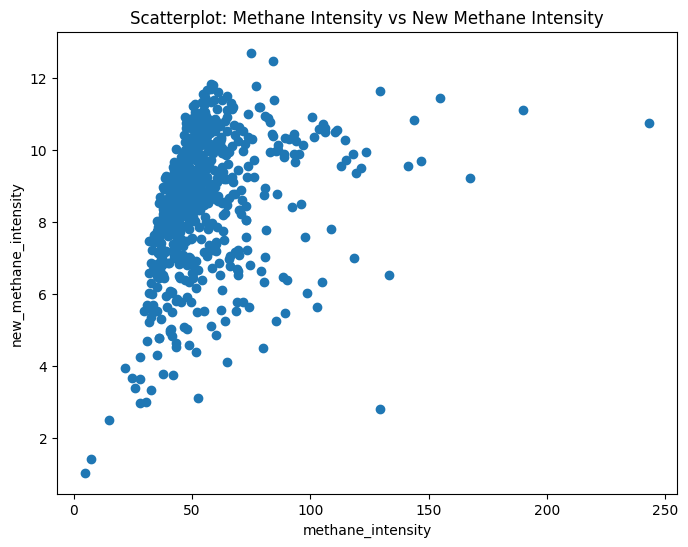

In [228]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    calculated_gas["methane_intensity"],
    calculated_gas["new_methane_intensity"]
)

plt.xlabel("methane_intensity")
plt.ylabel("new_methane_intensity")
plt.title("Scatterplot: Methane Intensity vs New Methane Intensity")

plt.show()

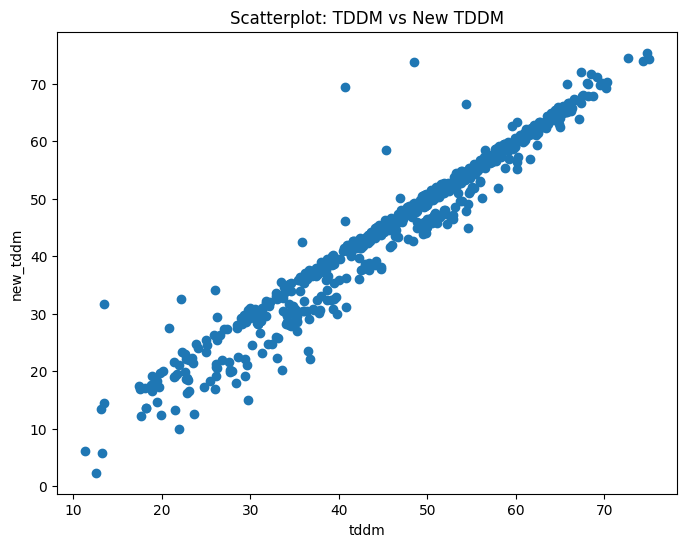

In [223]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    calculated_gas["tddm"],
    calculated_gas["new_tddm"]
)

plt.xlabel("tddm")
plt.ylabel("new_tddm")
plt.title("Scatterplot: TDDM vs New TDDM")

plt.show()